# 07 — Rational Expressions

**Topic 7 of the syllabus (Review).**

A **rational expression** is a fraction whose top and bottom are polynomials, like

$$\frac{x^{2}-1}{x^{2}-x-2}, \qquad \frac{1}{x}, \qquad \frac{3x+5}{7} .$$

The word *rational* here does not mean "sensible". It comes from **ratio**, which means a
division of one thing by another. It is the same word as in "rational number" — a ratio of two
whole numbers.

This notebook is the payoff for the last two. Everything we built is now used:

* **factoring** (notebook 05) — because you cancel a rational expression by factoring it;
* **division** (notebooks 04 and 06) — because a heavy fraction splits into a polynomial plus a
  light fraction;
* **unique factorisation** (notebook 05, Theorem 16) — because it is what makes "lowest terms"
  mean something.

And one brand-new danger appears, which did not exist for polynomials: **a rational expression
is not defined everywhere.** Dividing by zero is not allowed, so some values of $x$ are simply
forbidden. Half the mistakes in this topic come from forgetting that.

---

## 0. What we need from before (read this first)

Quick recall. If any line here feels unfamiliar, go back to that notebook before continuing —
this one is built directly on top of them.

| We will use | Where it was proved | What it says |
| --- | --- | --- |
| Zero-product property | nb 01, nb 05 Thm 1 | $ab=0$ only if $a=0$ or $b=0$ |
| Factoring toolkit | nb 05 §3 | GCF, grouping, special products, trinomials, $ac$ method |
| Rational root theorem | nb 05 Thm 12 | where to look for the roots of a denominator |
| Unique factorisation | nb 05 Thm 16 | a polynomial factors into irreducibles in one way only |
| Bézout for polynomials | nb 05 Lemma 14 | coprime $\Rightarrow$ $au+bv=1$ for some polynomials $u,v$ |
| Division algorithm | nb 04 Thm 5 | $f=gq+r$, with $\deg r<\deg g$, and it is **unique** |
| At most $n$ roots | nb 04 Thm 8 | a non-zero polynomial of degree $n$ has at most $n$ roots |
| Identity theorem | nb 04 Thm 9 | agreeing for every $x$ $\iff$ same coefficient list |
| Synthetic division | nb 06 Thm 2 | a fast way to divide by $x-c$ and to test a root |

Two questions before you scroll on. Answer them in your head, honestly:

1. Why is "cancel a *factor*" allowed but "cancel a *term*" not? (Trap 5 of notebook 05.)
2. What exactly does the identity theorem let you do that you could not do without it?

---

## 1. Intuition first

### 1.1 The same step we took with numbers

We have done this before. Twice.

| We had | It was missing | So we built | And gained |
| --- | --- | --- | --- |
| whole numbers $\mathbb{Z}$ | you cannot always divide | fractions $\mathbb{Q}$ | division by anything except $0$ |
| polynomials $\mathbb{R}[x]$ | you cannot always divide | **rational expressions $\mathbb{R}(x)$** | division by anything except $0$ |

Look at the two rows. They are the same story. $5\div 3$ is not a whole number, so we invented
$\tfrac53$. In the same way $1\div x$ is not a polynomial (notebook 04 proved this), so we
invent the new object $\tfrac1x$.

The notation for the new set is $\mathbb{R}(x)$ with **round** brackets — compare $\mathbb{R}[x]$
with square brackets for polynomials. Square brackets: only $+,-,\times$. Round brackets:
division allowed too.

Everything you know about fractions of numbers will carry over: same rules for adding,
multiplying, cancelling. That is not luck. It is because both are built the same way, and we
will prove the rules rather than assume them.

### 1.2 The new danger: forbidden points

Here is the one real difference, and it is important.

$$\frac{5}{3} \text{ is a number.} \qquad \frac{1}{x} \text{ is not a number — it depends on } x.$$

And when $x=0$, the expression $\tfrac1x$ means $1\div0$, which does not exist. So $\tfrac1x$
is defined for every real number **except** $0$.

Every rational expression carries this baggage: a short list of forbidden $x$-values, the ones
where the bottom is zero. The set of allowed values is called the **domain**.

### 1.3 The trap that this topic is famous for

Look at

$$R(x)=\frac{x^{2}-1}{x-1}=\frac{(x-1)(x+1)}{x-1}.$$

Cancel the $(x-1)$ and you get $x+1$. That is correct — *almost*. The two expressions agree at
every $x$ **except** $x=1$, where the first one is $\tfrac00$ (undefined) and the second one is
$2$ (perfectly fine).

So they are **not the same object**. The graph of $R$ is the line $y=x+1$ with a single point
removed. That missing point is called a **hole**.

The picture below draws it. Look carefully at the little open circle.

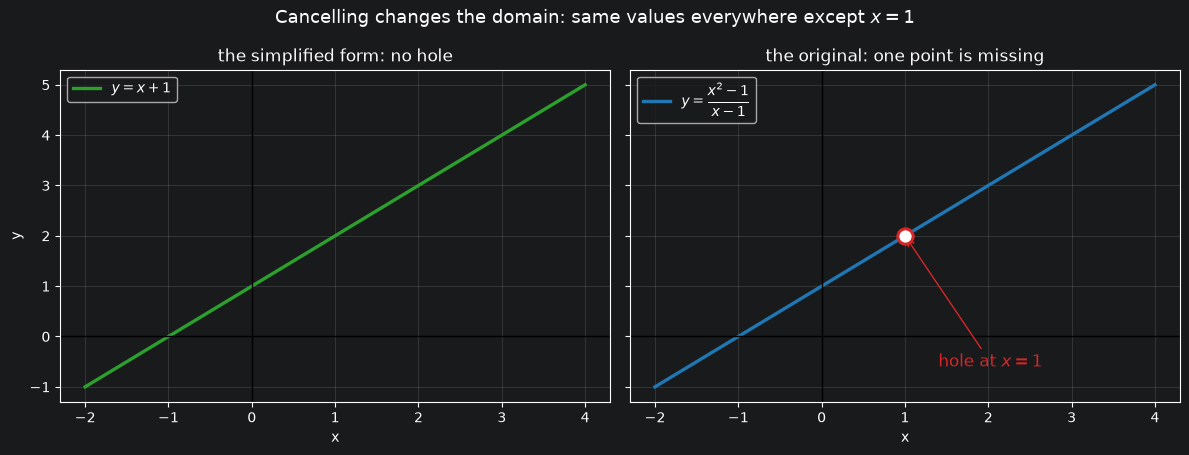

In [5]:
# --- picture: cancelling leaves a hole behind ---

import numpy as np                    # np = the fast-numbers tool (arrays, powers, roots)
import matplotlib.pyplot as plt       # plt = matplotlib's drawing tool

# Colour code used in the WHOLE notebook, so every picture speaks the same language:
C_MAIN = "#1f77b4"   # blue   -> the rational expression we are studying
C_ALT  = "#d62728"   # red    -> a forbidden point, an asymptote, a warning
C_FILL = "#2ca02c"   # green  -> the simplified answer / the correct thing
C_GREY = "#7f7f7f"   # grey   -> helper lines and labels

x = np.linspace(-2.0, 4.0, 601)       # 601 evenly spaced x-values from -2 to 4

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True)

# LEFT: the simplified expression x + 1 -- an ordinary straight line, defined everywhere
axes[0].plot(x, x + 1, color=C_FILL, linewidth=2.4, label=r"$y=x+1$")
axes[0].set_title("the simplified form: no hole")

# RIGHT: the original (x^2-1)/(x-1). We must NOT evaluate it at x = 1.
mask = np.abs(x - 1.0) > 1e-9         # True everywhere except at x = 1
xr = x[mask]                          # keep only the allowed x-values
axes[1].plot(xr, (xr**2 - 1) / (xr - 1), color=C_MAIN, linewidth=2.4,
             label=r"$y=\dfrac{x^2-1}{x-1}$")
# an OPEN circle at (1, 2): white inside, red edge -- the standard way to draw "point missing"
axes[1].plot([1], [2], "o", markersize=11, markerfacecolor="white",
             markeredgecolor=C_ALT, markeredgewidth=2.2, zorder=5)
axes[1].annotate("hole at $x=1$", xy=(1, 2), xytext=(1.4, -0.6), color=C_ALT, fontsize=12,
                 arrowprops=dict(arrowstyle="->", color=C_ALT))
axes[1].set_title("the original: one point is missing")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)      # the horizontal axis y = 0
    ax.axvline(0, color="black", linewidth=1)      # the vertical axis x = 0
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")
axes[0].set_ylabel("y")
fig.suptitle("Cancelling changes the domain: same values everywhere except $x=1$", fontsize=13)
fig.tight_layout()
plt.show()

### 1.4 Cancel factors, not terms

This is Trap 5 from notebook 05, and now it is the main event.

**Allowed** (it is a factor of the *whole* top and the *whole* bottom):

$$\frac{(x-1)(x+1)}{(x-1)\cdot 1}=\frac{x+1}{1}=x+1 \qquad (x\neq1).$$

**Not allowed** (it is only a *term*, one piece of a sum):

$$\frac{x+3}{x} \;\neq\; 3 .$$

Test it with a number: at $x=1$ the left side is $\tfrac{4}{1}=4$ and the right side is $3$.
One counterexample is enough to kill a claim forever — this is the cheapest and most powerful
checking habit in all of mathematics.

Why is one allowed and the other not? Because cancelling is really this rule:

$$\frac{d\cdot a}{d\cdot b}=\frac{a}{b} \qquad (d\neq0,\ b\neq0),$$

and it needs $d$ to be **multiplying** the whole top and the whole bottom. In $\tfrac{x+3}{x}$
the $x$ on top is *added* to $3$, not multiplying $(x+3)$. The picture makes the difference
loud.

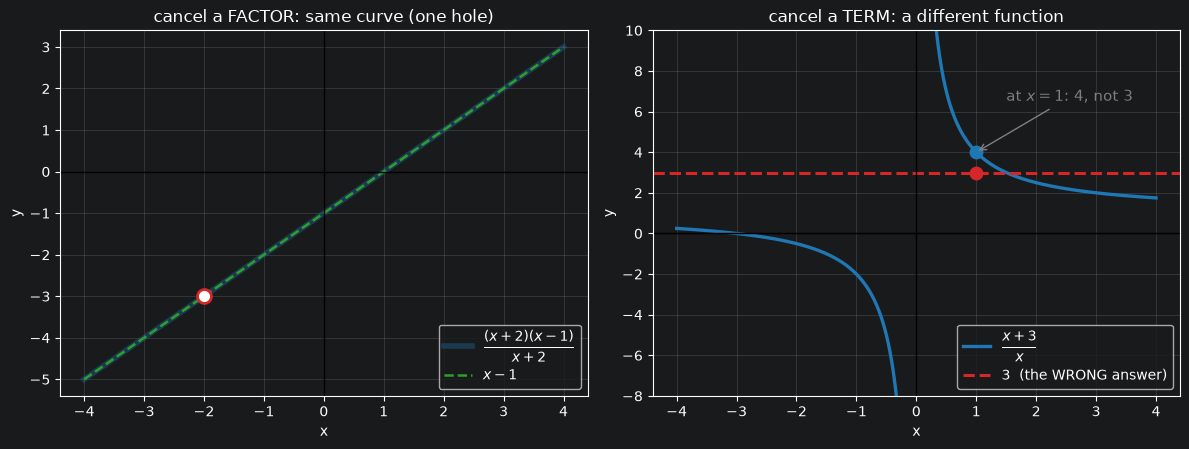

In [6]:
# --- picture: one cancellation is legal, the other destroys the function ---

x = np.linspace(-4.0, 4.0, 801)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

# LEFT: cancelling a FACTOR -- the two curves lie exactly on top of each other (except a hole)
mask = np.abs(x + 2) > 1e-9                       # x = -2 is forbidden on the left picture
xl = x[mask]
axes[0].plot(xl, ((xl + 2) * (xl - 1)) / (xl + 2), color=C_MAIN, linewidth=4.0, alpha=0.35,
             label=r"$\dfrac{(x+2)(x-1)}{x+2}$")
axes[0].plot(x, x - 1, color=C_FILL, linewidth=1.8, linestyle="--", label=r"$x-1$")
axes[0].plot([-2], [-3], "o", markersize=10, markerfacecolor="white",
             markeredgecolor=C_ALT, markeredgewidth=2.0, zorder=5)
axes[0].set_title("cancel a FACTOR: same curve (one hole)")

# RIGHT: cancelling a TERM -- two completely different curves
mask = np.abs(x) > 1e-9                           # x = 0 is forbidden
xr2 = x[mask]
axes[1].plot(xr2[xr2 < 0], (xr2[xr2 < 0] + 3) / xr2[xr2 < 0], color=C_MAIN, linewidth=2.4)
axes[1].plot(xr2[xr2 > 0], (xr2[xr2 > 0] + 3) / xr2[xr2 > 0], color=C_MAIN, linewidth=2.4,
             label=r"$\dfrac{x+3}{x}$")
axes[1].axhline(3, color=C_ALT, linewidth=2.2, linestyle="--", label=r"$3$  (the WRONG answer)")
axes[1].plot([1], [4], "o", color=C_MAIN, markersize=9)
axes[1].plot([1], [3], "o", color=C_ALT, markersize=9)
axes[1].annotate("at $x=1$: $4$, not $3$", xy=(1, 4), xytext=(1.5, 6.5), color=C_GREY,
                 fontsize=11, arrowprops=dict(arrowstyle="->", color=C_GREY))
axes[1].set_ylim(-8, 10)
axes[1].set_title("cancel a TERM: a different function")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
plt.show()

### 1.5 Holes and walls

A rational expression can fail in two very different ways at a forbidden point.

* If the bottom's factor **cancels** with the top, you get a **hole**: one missing point, and
  the curve carries on either side as if nothing happened.
* If the factor **does not cancel**, you get a **vertical asymptote** — a wall. Near that
  $x$-value the expression runs off to $+\infty$ or $-\infty$.

The word *asymptote* means a line that the curve gets closer and closer to without ever
touching. We will meet them properly in the chapter on rational *functions*; for now just learn
to tell the two apart, because the test is pure algebra: **factor the top and the bottom, and
see what cancels.**

### 1.6 The plan of this notebook

1. Define a rational expression, its **domain**, and what it means for two of them to be equal.
2. Prove the arithmetic: cancel, multiply, divide, add, subtract — and prove that
   $\mathbb{R}(x)$ is a **field**, the same word we used for the axioms of $\mathbb{R}$ in
   notebook 01.
3. Prove that **lowest terms** exist and are essentially unique.
4. Split any rational expression into *polynomial + small fraction*, using the division
   algorithm.
5. The summit: **partial fractions** — break a complicated fraction into a sum of simple ones.
   The proof is short, and it hands you **Lagrange interpolation** for free, which is a tool
   you will meet again in machine learning.

---

## 2. Formal definitions

**Definition 1 (rational expression).** A **rational expression** is a quotient

$$R=\frac{p}{q}$$

where $p$ and $q$ are polynomials and $q$ is **not the zero polynomial**. The polynomial $p$ is
the **numerator** (the top), $q$ is the **denominator** (the bottom).

Note carefully: "$q$ is not the zero polynomial" means $q$ is not the polynomial $0$. It does
**not** mean $q(x)\neq0$ for every $x$ — that would be far too strong. $q(x)=x$ is allowed; it
is only the single value $x=0$ that will be forbidden.

The set of all rational expressions with real coefficients is written $\mathbb{R}(x)$, with
round brackets.

**Definition 2 (domain).** The **domain** of $R=\dfrac{p}{q}$ is the set

$$\operatorname{dom}(R)=\{\,x\in\mathbb{R}\;:\;q(x)\neq0\,\}.$$

The values where $q(x)=0$ are the **forbidden values** (or excluded values). At those $x$ the
expression has no meaning at all — it is not "infinity", it is *nothing*.

**Rule that you must never break:** find the domain from the **original** expression, before
you cancel anything. Section 1.3 showed why.

**Definition 3 (the rational function).** Once the domain is fixed, $R$ defines a function

$$R:\operatorname{dom}(R)\to\mathbb{R},\qquad x\mapsto \frac{p(x)}{q(x)} .$$

The arrow $\mapsto$ is read "maps to". This is the *function* attached to the expression.

**Definition 4 (equality — two meanings).** Let $R_{1}=\dfrac{p_{1}}{q_{1}}$ and
$R_{2}=\dfrac{p_{2}}{q_{2}}$.

* **(A) Equal as fractions:** $p_{1}q_{2}=p_{2}q_{1}$ as polynomials. (This is "cross-multiply".)
* **(B) Equal as functions:** $R_{1}(x)=R_{2}(x)$ for every $x$ where **both** are defined.

Theorem 2 will prove that (A) and (B) say the same thing. Until then, keep them apart in your
mind: they are different definitions, and it is not obvious that they agree.

**Definition 5 (lowest terms).** $\dfrac{a}{b}$ is in **lowest terms** if $a$ and $b$ have no
common factor except constants. (Constants can never be removed in a useful way, because
$\tfrac{2}{4}$ and $\tfrac{1}{2}$ are the same thing.)

**Definition 6 (proper and improper).** $\dfrac{p}{q}$ is **proper** if $\deg p<\deg q$, and
**improper** if $\deg p\ge\deg q$. Exactly like $\tfrac{3}{7}$ (proper) against $\tfrac{7}{3}$
(improper) for numbers.

**Definition 7 (LCD).** Given denominators $q_{1},\dots,q_{k}$, a **common denominator** is a
polynomial that every $q_{i}$ divides. The **least common denominator (LCD)** is a common
denominator of smallest degree. Theorem 8 will show how to build it and that it is essentially
unique.

**Definition 8 (complex fraction).** A **complex fraction** (also called a compound fraction) is
a fraction that has fractions inside it, like

$$\frac{\dfrac1x+\dfrac1y}{\dfrac1x-\dfrac1y}.$$

The word *complex* here means "made of several parts". It has **nothing** to do with complex
numbers — those come in the next chapter of the syllabus.

**Definition 9 (field).** A **field** is a set with $+$, $-$, $\times$, $\div$ that obeys the
axioms of notebook 01: both operations commutative and associative, a $0$ and a $1$, every
element has a negative, and every element except $0$ has a reciprocal, plus the distributive
law. $\mathbb{Q}$ and $\mathbb{R}$ are fields. $\mathbb{Z}$ is **not** (it has no $\tfrac12$),
and $\mathbb{R}[x]$ is **not** (it has no $\tfrac1x$). Theorem 5 proves $\mathbb{R}(x)$ **is**.

---

## 3. Theorems, with full proofs

### 3.1 The domain is almost everything

**Theorem 1 (few forbidden points).**
Let $R=\dfrac{p}{q}$ with $\deg q=n\ge0$. Then at most $n$ real numbers are forbidden. In
particular the domain is never empty; it is all of $\mathbb{R}$ with a finite set removed.

**Proof.**
The forbidden values are exactly the real roots of $q$. Since $q$ is not the zero polynomial,
notebook 04 Theorem 8 says it has at most $\deg q=n$ real roots. A set of at most $n$ numbers
cannot be all of $\mathbb{R}$, because $\mathbb{R}$ is infinite. $\blacksquare$

Small but important: it tells us that any two rational expressions can be compared on a set
that is still infinite — and *that* is what makes the next theorem work.

### 3.2 The two meanings of "equal" agree

**Theorem 2 (cross-multiplying is legal).**
$\dfrac{p_{1}}{q_{1}}$ and $\dfrac{p_{2}}{q_{2}}$ are equal as functions (Definition 4B) **if
and only if** $p_{1}q_{2}=p_{2}q_{1}$ as polynomials (Definition 4A).

**Proof.**
($\Leftarrow$) Suppose $p_{1}q_{2}=p_{2}q_{1}$ as polynomials. Take any $x$ where both
expressions are defined, so $q_{1}(x)\neq0$ and $q_{2}(x)\neq0$. Putting that $x$ into the
polynomial identity gives the *number* equation $p_{1}(x)q_{2}(x)=p_{2}(x)q_{1}(x)$. Divide
both sides by the non-zero number $q_{1}(x)q_{2}(x)$:

$$\frac{p_{1}(x)}{q_{1}(x)}=\frac{p_{2}(x)}{q_{2}(x)} .$$

($\Rightarrow$) Suppose the two agree at every $x$ where both are defined. By Theorem 1 only
finitely many $x$ are forbidden, so they agree on an **infinite** set $S$. For $x\in S$,
multiply the equation $\dfrac{p_{1}(x)}{q_{1}(x)}=\dfrac{p_{2}(x)}{q_{2}(x)}$ by
$q_{1}(x)q_{2}(x)$, which is a non-zero number:

$$p_{1}(x)q_{2}(x)-p_{2}(x)q_{1}(x)=0 \qquad\text{for every } x\in S .$$

The left-hand side is a polynomial (notebook 04 Theorem 1), and it has infinitely many roots.
By notebook 04 Theorem 8, a non-zero polynomial of degree $n$ has at most $n$ roots — so this
polynomial must be the **zero** polynomial. That is exactly $p_{1}q_{2}=p_{2}q_{1}$.
$\blacksquare$

From now on we may write $=$ between rational expressions without saying which meaning we
intend. That freedom was earned, not assumed.

### 3.3 The fundamental principle: cancelling

**Theorem 3 (cancelling a common factor).**
Let $d,a,b$ be polynomials with $d\neq0$ and $b\neq0$ (as polynomials). Then

$$\frac{d\,a}{d\,b}=\frac{a}{b},$$

meaning: for every $x$ with $d(x)b(x)\neq0$, the two sides have the same value. Moreover the
right-hand side may be defined at *more* points than the left-hand side.

**Proof.**
By Theorem 2 it is enough to check the polynomial identity $(da)\cdot b=a\cdot(db)$. Both sides
equal $abd$, using only that multiplication of polynomials is commutative and associative
(notebook 04, Theorem 1 and the definition of the product). So the two expressions are equal.

For the last sentence: the left side is undefined wherever $d(x)b(x)=0$, the right side only
where $b(x)=0$. Every root of $b$ is a root of $db$, but a root of $d$ need not be a root of
$b$. So the domain can only grow. $\blacksquare$

**The warning, stated formally.** Theorem 3 is an equality *of expressions*, not of *functions
with their domains*. The functions agree on the smaller domain and nowhere else, because the
left-hand function does not exist outside it. Whenever you cancel, write the forbidden values
next to your answer:

$$\frac{(x-1)(x+1)}{x-1}=x+1 \qquad (x\neq1).$$

The little bracket at the end is not decoration. It is part of the answer.

**Why "cancel a term" is not a special case.** Someone cancelling in $\dfrac{x+3}{x}$ is trying
to use Theorem 3 with $d=x$, $a$ and $b$ unknown. For that they would need $x+3=x\cdot a$ for
some polynomial $a$ — that is, $x$ would have to *divide* $x+3$. It does not: by the factor
theorem (notebook 04 Theorem 7), $x$ divides $x+3$ only if $0+3=0$, which is false. So the
hypothesis of Theorem 3 fails, and nothing may be cancelled.

### 3.4 The arithmetic rules, proved

**Theorem 4 (the four operations).**
Let $\dfrac{p_{1}}{q_{1}}$ and $\dfrac{p_{2}}{q_{2}}$ be rational expressions. Then, at every
$x$ where both are defined:

$$\textbf{(i)}\quad \frac{p_{1}}{q_{1}}\cdot\frac{p_{2}}{q_{2}}=\frac{p_{1}p_{2}}{q_{1}q_{2}},
\qquad
\textbf{(ii)}\quad \frac{p_{1}}{q_{1}}\pm\frac{p_{2}}{q_{2}}=\frac{p_{1}q_{2}\pm p_{2}q_{1}}{q_{1}q_{2}},$$

$$\textbf{(iii)}\quad \frac{\;\dfrac{p_{1}}{q_{1}}\;}{\;\dfrac{p_{2}}{q_{2}}\;}
=\frac{p_{1}q_{2}}{q_{1}p_{2}} \quad(\text{where } p_{2}(x)\neq0 \text{ too}).$$

In every case the result is again a rational expression: the set $\mathbb{R}(x)$ is **closed**
under $+,-,\times$ and under $\div$ by anything that is not the zero expression.

**Proof.**
Fix an $x$ in the common domain. Then $p_{1}(x),q_{1}(x),p_{2}(x),q_{2}(x)$ are ordinary real
numbers with $q_{1}(x)\neq0\neq q_{2}(x)$. So each identity is just the corresponding rule for
**numbers**, which we proved from the axioms in notebook 01:

$$\frac{A}{B}\cdot\frac{C}{D}=\frac{AC}{BD},\qquad
\frac{A}{B}+\frac{C}{D}=\frac{AD+CB}{BD},\qquad
\frac{A/B}{C/D}=\frac{AD}{BC}.$$

Since this holds for every $x$ in an infinite set, Theorem 2 upgrades it to an equality of
expressions.

Closure: $p_{1}p_{2}$, $q_{1}q_{2}$ and $p_{1}q_{2}\pm p_{2}q_{1}$ are polynomials by
notebook 04 Theorem 1. And $q_{1}q_{2}$ is not the zero polynomial: if it were, then by
$\deg(q_{1}q_{2})=\deg q_{1}+\deg q_{2}$ (notebook 04 Theorem 2) — or directly by the
zero-product property — one of $q_{1},q_{2}$ would be zero, which is not allowed by
Definition 1. So the answer fits Definition 1. $\blacksquare$

**Note the shape of that proof.** We did not re-prove the fraction rules. We *transported* them:
every statement about rational expressions becomes a statement about numbers once you plug in a
value of $x$, and Theorem 2 carries the result back. This move will be used again and again.

### 3.5 $\mathbb{R}(x)$ is a field

**Theorem 5.** $\mathbb{R}(x)$, with the operations of Theorem 4, is a **field** (Definition 9).

**Proof.**
Commutativity, associativity and distributivity are inherited: by Theorem 2 it is enough to
check each axiom at every $x$ in a common domain, where it becomes the same axiom for real
numbers (notebook 01).

The zero element is the expression $\dfrac{0}{1}$ and the one element is $\dfrac{1}{1}$. The
negative of $\dfrac pq$ is $\dfrac{-p}{q}$, since $\dfrac pq+\dfrac{-p}{q}=\dfrac{p-p}{q}
=\dfrac0q=0$.

The interesting axiom is the **reciprocal**. Let $R=\dfrac pq$ be not the zero expression, that
is $p$ is not the zero polynomial. Then $\dfrac qp$ is a legal rational expression (Definition 1
only asks the *bottom* to be a non-zero polynomial, and $p$ is one), and by Theorem 4(i)

$$\frac pq\cdot\frac qp=\frac{pq}{qp}=1 .$$

So every non-zero element has a reciprocal, and $\mathbb{R}(x)$ is a field. $\blacksquare$

**Why this is worth a theorem.** Compare with $\mathbb{R}[x]$: there, $\tfrac{1}{x}$ does not
exist, so polynomials are not a field. Building $\mathbb{R}(x)$ repaired exactly one thing —
division — in the same way that building $\mathbb{Q}$ from $\mathbb{Z}$ did. The price we paid
is the domain problem: the objects of $\mathbb{R}(x)$ are no longer defined at every point.
Every extension in mathematics has a price; a good mathematician knows what it was.

### 3.6 Lowest terms

To simplify a fraction of numbers you cancel common factors until nothing is left to cancel.
For polynomials we can do the same, but we must *prove* that it works and that everybody
arrives at the same answer. The tools are Bézout and unique factorisation from notebook 05.

**Lemma 6a (Bézout when there is no common factor).**
If the polynomials $a$ and $b$ have no common factor except constants, then there are
polynomials $u,v$ with

$$a\,u+b\,v=1 .$$

**Proof.** Notebook 05 Lemma 14 gives a polynomial $d=au_{0}+bv_{0}$ of smallest degree that
divides both $a$ and $b$. So $d$ is a common factor of $a$ and $b$ — and by assumption the only
common factors are constants. Hence $d$ is a non-zero constant $\lambda$ (it cannot be $0$,
because $0$ does not divide a non-zero polynomial). Divide $\lambda=au_{0}+bv_{0}$ by $\lambda$
and set $u=u_{0}/\lambda$, $v=v_{0}/\lambda$. $\blacksquare$

**Lemma 6b (the cancellation lemma).**
If $b$ divides $a\,b'$ and $a,b$ have no common non-constant factor, then $b$ divides $b'$.

**Proof.** By Lemma 6a pick $u,v$ with $au+bv=1$. Multiply the whole equation by $b'$:

$$a b' u + b b' v = b' .$$

Now look at the left side. $b$ divides $ab'$ by assumption, so it divides $ab'u$. And $b$
obviously divides $bb'v$. A sum of two multiples of $b$ is a multiple of $b$, so $b$ divides
the left side — which *is* $b'$. $\blacksquare$

**Theorem 6 (lowest terms: existence and uniqueness).**
Every rational expression $\dfrac pq$ (with $p\neq0$) equals some $\dfrac ab$ in lowest terms.
Moreover, if $\dfrac ab=\dfrac{a'}{b'}$ and both are in lowest terms, then there is a non-zero
constant $\lambda$ with

$$a'=\lambda a,\qquad b'=\lambda b .$$

So "the" reduced form is unique apart from an overall constant, which is exactly the freedom
$\tfrac12=\tfrac24$ has for numbers.

**Proof of existence.**
By notebook 05 Theorem 16 write $p$ and $q$ as constants times products of irreducible
polynomials. If some irreducible $P$ appears in both lists, then $p=P\tilde p$ and
$q=P\tilde q$, and Theorem 3 lets us cancel it: $\dfrac pq=\dfrac{\tilde p}{\tilde q}$. Each
cancellation lowers $\deg p+\deg q$ by at least $2$, so the process stops after finitely many
steps (this is the well-ordering principle again, as in notebook 05). Call the result
$\dfrac ab$.

Why is $\dfrac ab$ in lowest terms? Suppose $f$ were a common non-constant factor of $a$ and
$b$. Factor $f$ into irreducibles (Theorem 16 again) and take one of them, $P$. Then $P$ divides
$a$ and $P$ divides $b$, so by the **uniqueness** half of Theorem 16 the irreducible $P$ appears
in the factor list of $a$ and in the factor list of $b$ — contradicting the fact that we removed
every shared irreducible. $\blacksquare$

**Proof of uniqueness.**
Suppose $\dfrac ab=\dfrac{a'}{b'}$, both in lowest terms. By Theorem 2 (cross-multiplying),

$$a\,b'=a'\,b .$$

Read the right-hand side: $b$ divides $a'b$, hence $b$ divides $ab'$. Since $a$ and $b$ have no
common non-constant factor, Lemma 6b gives $b\mid b'$. By exactly the same argument with the
roles swapped, $b'\mid b$.

Two polynomials that divide each other have the same degree (notebook 04 Theorem 2), so
$b'=\lambda b$ for a non-zero constant $\lambda$. Substituting into $ab'=a'b$ gives
$a\lambda b=a'b$, and cancelling the non-zero polynomial $b$ (allowed: if $(a\lambda-a')b=0$
then $a\lambda-a'=0$, because a product of non-zero polynomials is non-zero) gives
$a'=\lambda a$. $\blacksquare$

**What this theorem buys you.** When you simplify a rational expression by factoring, you cannot
"choose wrong". Any correct sequence of cancellations lands on the same answer up to a constant.
Without Theorem 16 of notebook 05, that would be a hope, not a fact.

### 3.7 Splitting off the polynomial part

**Theorem 7 (proper + improper).**
Let $\dfrac pq$ be any rational expression. Then there are **unique** polynomials $s$ and $r$
with

$$\frac pq = s + \frac rq, \qquad\text{where } r=0 \text{ or } \deg r<\deg q .$$

$s$ is the polynomial part and $\dfrac rq$ is a proper rational expression.

**Proof.**
*Existence.* By the division algorithm (notebook 04 Theorem 5) there are $s,r$ with $p=qs+r$
and $r=0$ or $\deg r<\deg q$. Divide the whole equation by $q$ — legal at every $x$ in the
domain — to get $\dfrac pq=s+\dfrac rq$.

*Uniqueness.* Suppose $s+\dfrac rq=s'+\dfrac{r'}q$ with both remainders proper. Multiply by $q$
(Theorem 2 again): $qs+r=qs'+r'$, hence

$$q\,(s-s')=r'-r .$$

If $s\neq s'$ the left side has degree $\deg q+\deg(s-s')\ge\deg q$ (notebook 04 Theorem 2),
while the right side is $0$ or has degree $<\deg q$ (notebook 04 Theorem 2, part 2). That is
impossible, so $s=s'$, and then $r=r'$. $\blacksquare$

This is the same statement as $\tfrac{7}{3}=2+\tfrac13$ for numbers. And there is a picture
hiding in it: far away from the forbidden points, $\dfrac rq$ becomes tiny, so the graph of
$\dfrac pq$ looks more and more like the graph of the polynomial $s$.

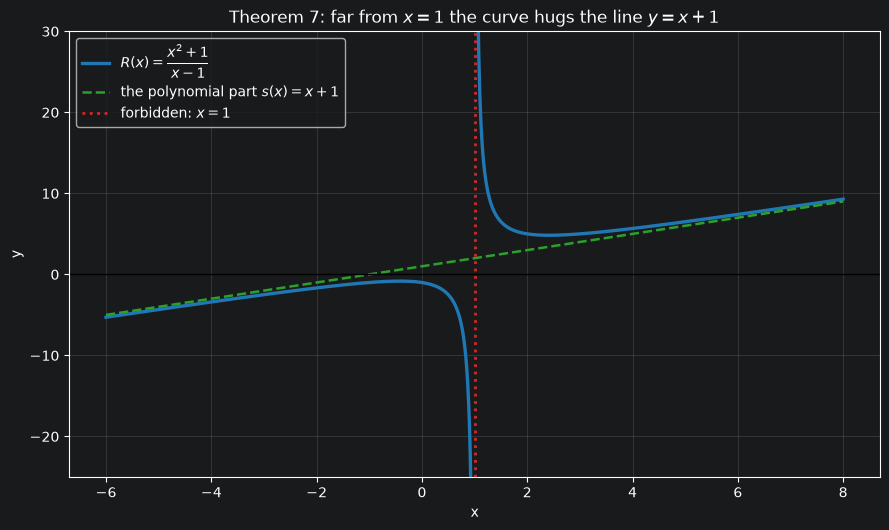

at x =     5.0:  R(x) - (x+1) = 0.500000    and 2/(x-1) = 0.500000
at x =    10.0:  R(x) - (x+1) = 0.222222    and 2/(x-1) = 0.222222
at x =   100.0:  R(x) - (x+1) = 0.020202    and 2/(x-1) = 0.020202
at x =  1000.0:  R(x) - (x+1) = 0.002002    and 2/(x-1) = 0.002002


In [7]:
# --- picture: the polynomial part is what the curve looks like far away ---

# (x^2 + 1)/(x - 1) = (x + 1) + 2/(x - 1)   [check: (x+1)(x-1) + 2 = x^2 - 1 + 2 = x^2 + 1]
x = np.linspace(-6.0, 8.0, 1401)
mask = np.abs(x - 1.0) > 0.06                 # stay away from the forbidden point x = 1
xs = x[mask]
R = (xs**2 + 1) / (xs - 1)

fig, ax = plt.subplots(figsize=(9.0, 5.4))

# draw the two branches separately, so matplotlib does not join them across the wall
left, right = xs < 1, xs > 1
ax.plot(xs[left], R[left], color=C_MAIN, linewidth=2.4)
ax.plot(xs[right], R[right], color=C_MAIN, linewidth=2.4,
        label=r"$R(x)=\dfrac{x^2+1}{x-1}$")

ax.plot(x, x + 1, color=C_FILL, linewidth=1.8, linestyle="--",
        label=r"the polynomial part $s(x)=x+1$")
ax.axvline(1, color=C_ALT, linewidth=2.0, linestyle=":", label=r"forbidden: $x=1$")

ax.set_ylim(-25, 30)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Theorem 7: far from $x=1$ the curve hugs the line $y=x+1$")
ax.axhline(0, color="black", linewidth=1)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# The gap between the curve and the line is exactly 2/(x-1) -- check it numerically:
for t in [5.0, 10.0, 100.0, 1000.0]:
    gap = (t**2 + 1) / (t - 1) - (t + 1)
    print(f"at x = {t:>7}:  R(x) - (x+1) = {gap:.6f}    and 2/(x-1) = {2/(t-1):.6f}")

### 3.8 The least common denominator

To add two fractions you need a common denominator. Theorem 4(ii) always gives you one —
$q_{1}q_{2}$ — but it is usually bigger than necessary, and a big denominator means a big mess.
The smallest choice is built from the factorisations.

**Lemma 8a (how divisibility looks in factored form).**
Write $f$ and $g$ as constants times products of powers of irreducibles,

$$f=c\,P_{1}^{e_{1}}\cdots P_{k}^{e_{k}},\qquad g=c'\,P_{1}^{f_{1}}\cdots P_{k}^{f_{k}}$$

(using the same list of irreducibles for both, with exponent $0$ where a factor is missing).
Then $f\mid g$ **if and only if** $e_{i}\le f_{i}$ for every $i$.

**Proof.**
($\Leftarrow$) If every $e_{i}\le f_{i}$ then $g=f\cdot\left(\frac{c'}{c}\prod_i
P_{i}^{f_{i}-e_{i}}\right)$, and the bracket is a polynomial because all exponents are $\ge0$.

($\Rightarrow$) If $g=fh$, factor $h$ into irreducibles (notebook 05 Theorem 16). Then the
factor list of $g$ is the factor list of $f$ together with the factor list of $h$. By the
**uniqueness** half of Theorem 16, the exponent of $P_{i}$ in $g$ is the exponent in $f$ plus
the exponent in $h$, which is $\ge e_{i}$. $\blacksquare$

**Theorem 8 (LCD).**
With the notation above, let

$$L=\prod_{i} P_{i}^{\,\max(e_{i},f_{i})}.$$

Then $f\mid L$ and $g\mid L$, and $L$ divides **every** common multiple of $f$ and $g$. In
particular $L$ has the smallest degree among common multiples, and it is unique up to a
constant.

**Proof.**
$f\mid L$ and $g\mid L$ follow from Lemma 8a, because $\max(e_{i},f_{i})\ge e_{i}$ and
$\ge f_{i}$.

Let $M$ be any common multiple, with exponents $m_{i}$. By Lemma 8a, $m_{i}\ge e_{i}$ and
$m_{i}\ge f_{i}$, so $m_{i}\ge\max(e_{i},f_{i})$. By Lemma 8a again, $L\mid M$. Then
$\deg L\le\deg M$ (notebook 04 Theorem 2), so $L$ has smallest degree; and if $M$ also had
smallest degree, $L$ and $M$ would divide each other and so differ only by a constant.
$\blacksquare$

**In practice.** Factor every denominator. For each different factor, take the **highest power**
that appears anywhere. Multiply those together. That is the LCD.

$$q_{1}=(x-1)^{2}(x+2),\qquad q_{2}=(x-1)(x+2)^{3}
\quad\Longrightarrow\quad L=(x-1)^{2}(x+2)^{3}.$$

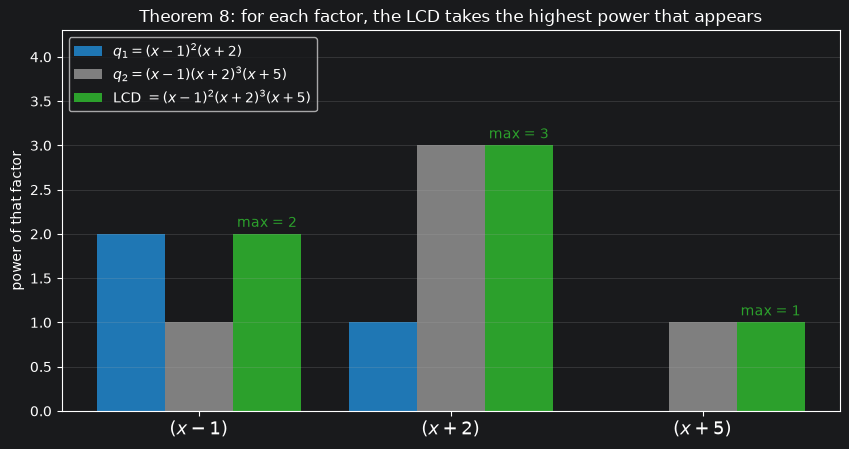

In [8]:
# --- picture: the LCD takes the HIGHEST power of each factor ---

factors = [r"$(x-1)$", r"$(x+2)$", r"$(x+5)$"]
q1_exp = [2, 1, 0]          # q1 = (x-1)^2 (x+2)
q2_exp = [1, 3, 1]          # q2 = (x-1) (x+2)^3 (x+5)
lcd_exp = [max(a, b) for a, b in zip(q1_exp, q2_exp)]   # the rule of Theorem 8

pos = np.arange(len(factors))          # 0, 1, 2 -- one slot per irreducible factor
width = 0.27

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(pos - width, q1_exp, width, color=C_MAIN, label=r"$q_1=(x-1)^2(x+2)$")
ax.bar(pos, q2_exp, width, color=C_GREY, label=r"$q_2=(x-1)(x+2)^3(x+5)$")
ax.bar(pos + width, lcd_exp, width, color=C_FILL,
       label=r"LCD $=(x-1)^2(x+2)^3(x+5)$")

for i, e in enumerate(lcd_exp):        # write the winning exponent above each green bar
    ax.text(pos[i] + width, e + 0.08, f"max = {e}", ha="center", color=C_FILL, fontsize=10)

ax.set_xticks(pos)
ax.set_xticklabels(factors, fontsize=13)
ax.set_ylabel("power of that factor")
ax.set_ylim(0, 4.3)
ax.set_title("Theorem 8: for each factor, the LCD takes the highest power that appears")
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

### 3.9 Holes and walls, as precisely as we can prove today

**Theorem 9 (what happens at a forbidden point).**
Let $\dfrac pq$ have reduced form $\dfrac ab$ (Theorem 6), and let $c$ be a forbidden value, so
$q(c)=0$. Exactly one of these holds:

* **(hole)** $b(c)\neq0$. Then the reduced expression $\dfrac ab$ *is* defined at $c$, with the
  value $\dfrac{a(c)}{b(c)}$, even though the original was not.
* **(wall)** $b(c)=0$. Then $a(c)\neq0$.

**Proof.**
The two cases are clearly exclusive and cover everything, so only the last claim needs work.
Suppose $b(c)=0$ and, for contradiction, also $a(c)=0$. By the factor theorem (notebook 04
Theorem 7), $(x-c)$ divides $a$ **and** divides $b$. That is a common non-constant factor, which
contradicts $\dfrac ab$ being in lowest terms (Definition 5). $\blacksquare$

**What we have *not* proved.** In the wall case, everyone will tell you that the values "run
off to infinity" near $c$. That statement is about a **limit**, and limits are not on our list of
proved things yet — this is the same honest gap we met in notebook 03 with the area of a circle.
What we *have* proved is the algebraic heart of it: the top is not zero while the bottom is, so
the fraction is a non-zero number divided by something arbitrarily small. Section 6 shows this
numerically. We will prove the limit statement properly when we do limits.

Keep the two words straight:

| | top cancels the factor? | at $x=c$ the graph has | test |
| --- | --- | --- | --- |
| **hole** | yes | one missing point | $b(c)\neq0$ after reducing |
| **wall (vertical asymptote)** | no | a vertical line it never crosses | $b(c)=0$ after reducing |

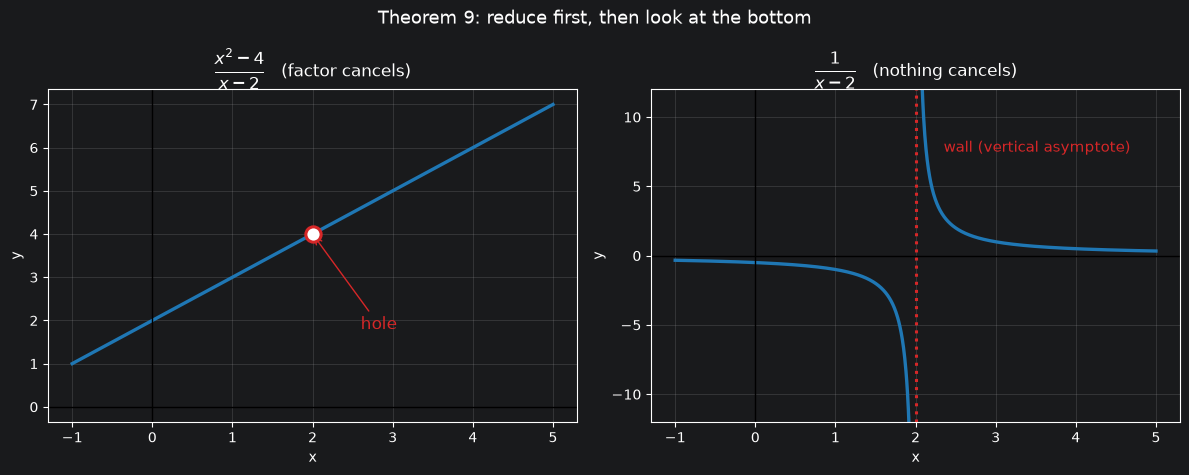

In [9]:
# --- picture: the same forbidden value, two completely different pictures ---

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

# LEFT: a HOLE. (x^2 - 4)/(x - 2) = x + 2, reduced bottom is 1, which is not 0 at x = 2.
x1 = np.linspace(-1.0, 5.0, 601)
m1 = np.abs(x1 - 2.0) > 1e-9
axes[0].plot(x1[m1], (x1[m1]**2 - 4) / (x1[m1] - 2), color=C_MAIN, linewidth=2.4)
axes[0].plot([2], [4], "o", markersize=11, markerfacecolor="white",
             markeredgecolor=C_ALT, markeredgewidth=2.2, zorder=5)
axes[0].annotate("hole", xy=(2, 4), xytext=(2.6, 1.8), color=C_ALT, fontsize=12,
                 arrowprops=dict(arrowstyle="->", color=C_ALT))
axes[0].set_title(r"$\dfrac{x^2-4}{x-2}$   (factor cancels)")

# RIGHT: a WALL. 1/(x-2) has nothing to cancel.
x2 = np.linspace(-1.0, 5.0, 1201)
m2 = np.abs(x2 - 2.0) > 0.02
xr = x2[m2]
y = 1 / (xr - 2)
axes[1].plot(xr[xr < 2], y[xr < 2], color=C_MAIN, linewidth=2.4)
axes[1].plot(xr[xr > 2], y[xr > 2], color=C_MAIN, linewidth=2.4)
axes[1].axvline(2, color=C_ALT, linewidth=2.2, linestyle=":")
axes[1].annotate("wall (vertical asymptote)", xy=(2, 6), xytext=(2.35, 7.5), color=C_ALT,
                 fontsize=11)
axes[1].set_ylim(-12, 12)
axes[1].set_title(r"$\dfrac{1}{x-2}$   (nothing cancels)")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
fig.suptitle("Theorem 9: reduce first, then look at the bottom", fontsize=13)
fig.tight_layout()
plt.show()

### 3.10 The summit: partial fractions

*(This section is the hardest one. Nothing later in the notebook depends on it, so if you are
tired, do the worked examples first and come back. But do come back — this is the most useful
thing in the whole topic, and the proof is short.)*

Adding fractions is easy:

$$\frac{1}{x-1}+\frac{2}{x+3}=\frac{(x+3)+2(x-1)}{(x-1)(x+3)}=\frac{3x+1}{x^{2}+2x-3}.$$

**Partial fractions** is the backwards question: given the messy answer, find the simple pieces.
Backwards questions are usually harder — but here we can answer completely, and the key is a
theorem about *building a polynomial through given points*.

**Theorem 10 (Lagrange interpolation).**
Let $r_{1},\dots,r_{n}$ be **distinct** real numbers and let $y_{1},\dots,y_{n}$ be any real
numbers. Then there is **exactly one** polynomial $L$ with $\deg L\le n-1$ and

$$L(r_{i})=y_{i}\quad\text{for } i=1,\dots,n .$$

**Proof of existence.** Build the *basis polynomials*

$$\ell_{i}(x)=\prod_{j\neq i}\frac{x-r_{j}}{r_{i}-r_{j}} .$$

The bottom is a non-zero number because the $r_{j}$ are distinct. Each $\ell_{i}$ is a product of
$n-1$ linear factors divided by a constant, so $\deg \ell_{i}=n-1$.

Now the trick. Put $x=r_{i}$: every fraction becomes $\frac{r_i-r_j}{r_i-r_j}=1$, so
$\ell_{i}(r_{i})=1$. Put $x=r_{k}$ with $k\neq i$: the factor with $j=k$ is
$\frac{r_k-r_k}{r_i-r_k}=0$, so the whole product is $0$. In short

$$\ell_{i}(r_{k})=\begin{cases}1 & k=i\\ 0 & k\neq i\end{cases}$$

— each $\ell_i$ is a switch that is on at its own point and off at all the others. Therefore

$$L(x)=\sum_{i=1}^{n}y_{i}\,\ell_{i}(x)$$

has degree $\le n-1$ and satisfies $L(r_{k})=\sum_i y_i\ell_i(r_k)=y_{k}$. ✓

**Proof of uniqueness.** If $L$ and $\tilde L$ both work, then $L-\tilde L$ has degree $\le n-1$
and vanishes at the $n$ distinct points $r_{1},\dots,r_{n}$. By notebook 04 Theorem 8 a non-zero
polynomial of degree $\le n-1$ has at most $n-1$ roots. So $L-\tilde L$ is the zero polynomial.
$\blacksquare$

**Theorem 11 (partial fractions, distinct linear factors).**
Let $q(x)=(x-r_{1})(x-r_{2})\cdots(x-r_{n})$ with the $r_{i}$ distinct, and let $p$ be a
polynomial with $\deg p<n$. Then there are **unique** constants $A_{1},\dots,A_{n}$ with

$$\frac{p(x)}{q(x)}=\frac{A_{1}}{x-r_{1}}+\frac{A_{2}}{x-r_{2}}+\dots+\frac{A_{n}}{x-r_{n}},$$

and they are given by the **cover-up formula**

$$\boxed{\;A_{i}=\frac{p(r_{i})}{\displaystyle\prod_{j\neq i}(r_{i}-r_{j})}\;}$$

— that is: cover up the factor $(x-r_{i})$ in $q$, and evaluate what is left at $x=r_{i}$.

**Proof.**
Multiply the claimed identity by $q$. Using $\dfrac{q(x)}{x-r_{i}}=\prod_{j\neq i}(x-r_{j})$,
the claim becomes the *polynomial* statement

$$p(x)=\sum_{i=1}^{n}A_{i}\prod_{j\neq i}(x-r_{j}). \qquad (\ast)$$

By Theorem 2 the two statements are equivalent, so we only have to solve $(\ast)$.

Now compare $(\ast)$ with Theorem 10. Set

$$A_{i}=\frac{p(r_{i})}{\prod_{j\neq i}(r_{i}-r_{j})},$$

so that $A_{i}\prod_{j\neq i}(x-r_{j})=p(r_{i})\,\ell_{i}(x)$. Then the right-hand side of
$(\ast)$ is exactly the Lagrange polynomial $L$ built from the points $r_{i}$ and the values
$p(r_{i})$. By Theorem 10 that $L$ is the *only* polynomial of degree $\le n-1$ passing through
those points — and $p$ itself is such a polynomial, because $\deg p<n$ and obviously
$p(r_{i})=p(r_{i})$. So $L=p$, which is $(\ast)$. ✓

*Uniqueness.* Suppose two sets of constants $A_{i}$ and $A_{i}'$ both satisfy $(\ast)$.
Subtracting the two versions gives

$$\sum_{i=1}^{n}(A_{i}-A_{i}')\prod_{j\neq i}(x-r_{j})=0 \qquad\text{for every } x .$$

Put $x=r_{k}$. Every product with $i\neq k$ contains the factor $(r_{k}-r_{k})=0$ and dies, so
only the $k$-th term survives: $(A_{k}-A_{k}')\prod_{j\neq k}(r_{k}-r_{j})=0$. That product is
not zero, because the $r$'s are distinct. So $A_{k}=A_{k}'$ for every $k$. $\blacksquare$

**Two remarks.**

1. The cover-up formula means you can write the answer down **without solving any system of
   equations**. Most textbooks teach the slow way first; you now have the proof of the fast way.
2. We have only handled *distinct linear* factors. Repeated factors like $(x-1)^{2}$ and
   irreducible quadratics like $x^{2}+1$ also have partial fraction expansions, but their proofs
   need more machinery. That is honestly **owed**, not done — see § 8.

**Why anyone cares.** In calculus, $\int\frac{3x+1}{x^{2}+2x-3}\,dx$ looks impossible and
$\int\frac{1}{x-1}dx+\int\frac{2}{x+3}dx$ is two easy integrals. In engineering, partial
fractions are how a transfer function is broken into simple modes. And Theorem 10 by itself —
one polynomial through $n$ points — is a workhorse of numerical mathematics.

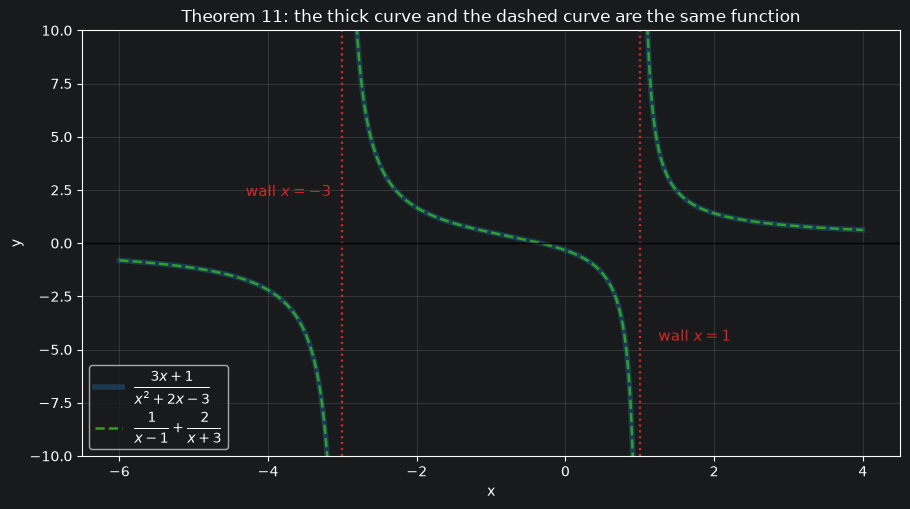

A1 = p(1)/(1-(-3)) = 1.0
A2 = p(-3)/((-3)-1) = 2.0


In [10]:
# --- picture: the messy fraction and the two simple pieces are the same curve ---

x = np.linspace(-6.0, 4.0, 2001)
bad = (np.abs(x - 1.0) < 0.05) | (np.abs(x + 3.0) < 0.05)     # stay off the two walls
xs = x[~bad]

messy = (3 * xs + 1) / (xs**2 + 2 * xs - 3)          # the single fraction
pieces = 1 / (xs - 1) + 2 / (xs + 3)                 # A1 = 1, A2 = 2 by the cover-up formula

fig, ax = plt.subplots(figsize=(9.2, 5.2))

# three separate branches, cut at the two walls, so nothing is joined across them
cuts = [xs < -3, (xs > -3) & (xs < 1), xs > 1]
for k, piece in enumerate(cuts):
    ax.plot(xs[piece], messy[piece], color=C_MAIN, linewidth=4.0, alpha=0.35,
            label=r"$\dfrac{3x+1}{x^2+2x-3}$" if k == 0 else None)
    ax.plot(xs[piece], pieces[piece], color=C_FILL, linewidth=1.8, linestyle="--",
            label=r"$\dfrac{1}{x-1}+\dfrac{2}{x+3}$" if k == 0 else None)

for wall in (-3.0, 1.0):
    ax.axvline(wall, color=C_ALT, linewidth=1.6, linestyle=":")
ax.text(-4.3, 2.2, r"wall $x=-3$", color=C_ALT, fontsize=11)
ax.text(1.25, -4.6, r"wall $x=1$", color=C_ALT, fontsize=11)

ax.set_ylim(-10, 10)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Theorem 11: the thick curve and the dashed curve are the same function")
ax.axhline(0, color="black", linewidth=1)
ax.legend(loc="lower left", fontsize=10)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# The cover-up formula, checked by hand:  q = (x-1)(x+3), p = 3x+1
print("A1 = p(1)/(1-(-3)) =", (3*1 + 1) / (1 + 3))
print("A2 = p(-3)/((-3)-1) =", (3*(-3) + 1) / (-3 - 1))

---

## 4. Traps

Nine ways to lose marks. Every one of them is a real mistake that real students make. For each,
the counterexample is the cure: **put in a number**.

**Trap 1 — cancelling a term.** $\dfrac{x+3}{x}\neq3$. Test at $x=1$: $4\neq3$. Cancelling needs
a factor of the **whole** top and the **whole** bottom (Theorem 3).

**Trap 2 — finding the domain after simplifying.** The forbidden values come from the
**original** bottom. $\dfrac{x^{2}-1}{x-1}=x+1$ *with $x\neq1$*. Write the restriction down.

**Trap 3 — the reversed bracket.** $\dfrac{x-3}{3-x}=-1$, not $+1$, for $x\neq3$. Because
$3-x=-(x-3)$. Whenever a bracket looks "backwards", pull out $-1$ first:

$$a-b=-(b-a).$$

**Trap 4 — inventing an addition rule.** $\dfrac1a+\dfrac1b\neq\dfrac{1}{a+b}$. Test with
$a=b=1$: the left is $2$, the right is $\tfrac12$. The correct rule is Theorem 4(ii).

**Trap 5 — losing the minus sign.** When subtracting, the whole numerator is subtracted:

$$\frac{A}{q}-\frac{B}{q}=\frac{A-B}{q}, \quad\text{so } \frac{2x+1}{q}-\frac{x-4}{q}
=\frac{2x+1-(x-4)}{q}=\frac{x+5}{q}\quad(\text{not } \tfrac{x-3}{q}).$$

Put the bracket in. Every time.

**Trap 6 — multiplying the LCD out too early.** Keep denominators **factored**:
$(x-1)(x+2)^{2}$, not $x^{3}+3x^{2}-4$. You will need those factors again to cancel at the end,
and multiplying them out throws the information away.

**Trap 7 — treating an expression like an equation.** In an *equation* you may multiply both
sides by the LCD, because both sides are the same number. An *expression* has no sides. If you
"clear the denominators" of an expression you have changed it into a different expression.
Compare: *simplify* $\dfrac1x+\dfrac12$ against *solve* $\dfrac1x+\dfrac12=1$.

**Trap 8 — half-multiplying a complex fraction.** If you multiply top and bottom by the LCD, it
must hit **every single term**, including terms that have no fraction in them.

**Trap 9 — calling every forbidden point a wall.** Reduce first. If the factor cancels, it is a
hole (Theorem 9). The graph of $\dfrac{x^{2}-4}{x-2}$ has no asymptote at all.

---

## 5. Worked examples

### Example 1 — domains

Find the domain of each expression.

**(a)** $\dfrac{5}{x-4}$. The bottom is zero when $x=4$. Domain: all real $x$ with $x\neq4$, in
interval notation (notebook 01) $(-\infty,4)\cup(4,\infty)$.

**(b)** $\dfrac{x+1}{x^{2}-x-6}$. Factor the bottom: $x^{2}-x-6=(x-3)(x+2)$. By the zero-product
property it is zero exactly when $x=3$ or $x=-2$. Domain: $x\neq3$ and $x\neq-2$.

**(c)** $\dfrac{x^{3}}{x^{2}+1}$. Can $x^{2}+1=0$? That needs $x^{2}=-1$, and a square is never
negative (notebook 01). Discriminant check: $D=0-4=-4<0$, so no real roots (notebook 05
Theorem 8). Domain: **all** real numbers. A rational expression is allowed to have no forbidden
points at all.

**(d)** $\dfrac{x^{2}-1}{x^{3}-x}$. Bottom $=x(x^{2}-1)=x(x-1)(x+1)$. Domain: $x\neq0,1,-1$.
Notice that *after* cancelling we will get $\dfrac1x$, which looks like it only forbids $0$ —
but Trap 2 says the answer keeps all three restrictions.

### Example 2 — simplify to lowest terms

$$\frac{x^{2}-9}{x^{2}-x-6}=\frac{(x-3)(x+3)}{(x-3)(x+2)}=\frac{x+3}{x+2}\qquad (x\neq3,\;x\neq-2).$$

Steps in order: factor top, factor bottom, **write the domain**, then cancel. Theorem 6 promises
that whatever route you take, the answer is the same up to a constant.

Check with a number: at $x=0$ the original is $\dfrac{-9}{-6}=\dfrac32$ and the answer is
$\dfrac{3}{2}$ ✓.

### Example 3 — a reversed bracket (Trap 3)

$$\frac{9-x^{2}}{x-3}=\frac{-(x^{2}-9)}{x-3}=\frac{-(x-3)(x+3)}{x-3}=-(x+3)\qquad(x\neq3).$$

Check at $x=0$: original $=\dfrac{9}{-3}=-3$; answer $=-(0+3)=-3$ ✓.

### Example 4 — multiplying

$$\frac{x^{2}-4}{x^{2}+4x+3}\cdot\frac{x^{2}+3x}{x^{2}-2x}.$$

Factor **everything first**, never multiply out:

$$=\frac{(x-2)(x+2)}{(x+1)(x+3)}\cdot\frac{x(x+3)}{x(x-2)} .$$

Forbidden values, read from the original bottoms *and* from the bottom of the second fraction:
$x\neq-1,-3,0,2$. Now cancel $(x+3)$, $x$ and $(x-2)$:

$$=\frac{x+2}{x+1}\qquad (x\neq-1,-3,0,2).$$

Four restrictions survive on an answer that shows only one of them. This is why you write them
down.

### Example 5 — dividing

$$\frac{\;\dfrac{x^{2}-1}{x+2}\;}{\;\dfrac{x-1}{x^{2}-4}\;}
=\frac{x^{2}-1}{x+2}\cdot\frac{x^{2}-4}{x-1}
=\frac{(x-1)(x+1)}{x+2}\cdot\frac{(x-2)(x+2)}{x-1}
=(x+1)(x-2),$$

valid for $x\neq-2,2,1$. Dividing by a fraction is multiplying by its reciprocal — Theorem 4(iii),
and note the extra condition there: you may only do it where the *dividing* expression is not
zero, which is why $x\neq1$ joins the list.

### Example 6 — adding with the LCD

$$\frac{3}{x^{2}-1}+\frac{2}{x^{2}+2x+1}.$$

Factor the bottoms: $(x-1)(x+1)$ and $(x+1)^{2}$. By Theorem 8 the LCD takes the highest power of
each factor:

$$L=(x-1)(x+1)^{2}.$$

Rewrite each fraction with bottom $L$ — multiply top and bottom by whatever is missing:

$$\frac{3}{(x-1)(x+1)}\cdot\frac{(x+1)}{(x+1)}=\frac{3(x+1)}{L},\qquad
\frac{2}{(x+1)^{2}}\cdot\frac{(x-1)}{(x-1)}=\frac{2(x-1)}{L}.$$

Add the tops:

$$\frac{3(x+1)+2(x-1)}{L}=\frac{3x+3+2x-2}{L}=\frac{5x+1}{(x-1)(x+1)^{2}}\qquad(x\neq1,-1).$$

Last step: can anything cancel? $5x+1$ has the single root $x=-\tfrac15$, which is neither $1$
nor $-1$, so no. The answer is in lowest terms.

### Example 7 — subtracting (Trap 5 live)

$$\frac{2x+1}{x-3}-\frac{x-4}{x-3}=\frac{(2x+1)-(x-4)}{x-3}=\frac{2x+1-x+4}{x-3}
=\frac{x+5}{x-3}\qquad(x\neq3).$$

The minus sign hits **both** terms of $x-4$. Forgetting that gives $\dfrac{x-3}{x-3}=1$, which
is a suspiciously tidy answer — tidy answers deserve a check. At $x=0$: the true value is
$\dfrac{1}{-3}-\dfrac{-4}{-3}=-\tfrac13-\tfrac43=-\tfrac53$, and our answer gives
$\dfrac{5}{-3}=-\tfrac53$ ✓. The wrong answer would have said $1$.

### Example 8 — a complex fraction, two ways

$$\frac{\;\dfrac1x+\dfrac1y\;}{\;\dfrac1x-\dfrac1y\;}\qquad (x\neq0,\;y\neq0,\;x\neq y).$$

**Method A (top and bottom separately).**

$$\frac1x+\frac1y=\frac{y+x}{xy},\qquad \frac1x-\frac1y=\frac{y-x}{xy},$$

so the whole thing is $\dfrac{(y+x)/xy}{(y-x)/xy}=\dfrac{y+x}{xy}\cdot\dfrac{xy}{y-x}
=\dfrac{x+y}{y-x}$.

**Method B (multiply everything by the inner LCD).** The inner denominators are $x$ and $y$, so
the LCD is $xy$. Multiply the top and the bottom of the big fraction by $xy$ — every term
(Trap 8):

$$\frac{\left(\dfrac1x+\dfrac1y\right)xy}{\left(\dfrac1x-\dfrac1y\right)xy}
=\frac{y+x}{y-x}.$$

Same answer, less writing. Method B is usually faster; Method A is safer when the pieces are
complicated. Both are justified by Theorem 4 and Theorem 3.

Why is $x\neq y$ needed? Because the bottom of the *original* is $\tfrac1x-\tfrac1y$, which is
zero exactly when $x=y$. Dividing by zero is forbidden even when the zero is hidden inside a
fraction.

### Example 9 — improper $\to$ polynomial + proper (with synthetic division)

$$\frac{x^{3}+2x^{2}-x+3}{x-2}.$$

The top has degree $3$, the bottom degree $1$, so this is improper (Definition 6) and
Theorem 7 applies. The divisor is $x-c$ with $c=2$, so use the table from notebook 06:

| $c=2$ | $1$ | $2$ | $-1$ | $3$ |
| --- | --- | --- | --- | --- |
| | | $2$ | $8$ | $14$ |
| | $\mathbf{1}$ | $\mathbf{4}$ | $\mathbf{7}$ | $\mathbf{17}$ |

So $x^{3}+2x^{2}-x+3=(x-2)(x^{2}+4x+7)+17$, and dividing by $x-2$:

$$\frac{x^{3}+2x^{2}-x+3}{x-2}=x^{2}+4x+7+\frac{17}{x-2}\qquad(x\neq2).$$

The remainder $17$ is $p(2)$ — the remainder theorem is still doing its job. And now you can see
the shape of the graph at a glance: far from $x=2$ it looks like the parabola $x^{2}+4x+7$, and
near $x=2$ the term $\tfrac{17}{x-2}$ takes over.

### Example 10 — the difference quotient (a taste of calculus)

For $f(x)=\dfrac1x$, simplify

$$\frac{f(x+h)-f(x)}{h}\qquad (h\neq0,\ x\neq0,\ x+h\neq0).$$

This measures how much $f$ changes, divided by how far you moved. Calculus is built on it.

$$\frac{\dfrac{1}{x+h}-\dfrac1x}{h}
=\frac{\dfrac{x-(x+h)}{x(x+h)}}{h}
=\frac{\dfrac{-h}{x(x+h)}}{h}
=\frac{-h}{x(x+h)}\cdot\frac1h
=\frac{-1}{x(x+h)} .$$

Look at what happened: the $h$ that made the expression look dangerous **cancelled**. That
cancellation is the whole trick of differential calculus, and § 6.6 will show that it also
makes the computation *numerically* safe.

### Example 11 — partial fractions with the cover-up rule

Split $\dfrac{5x-4}{(x-2)(x+1)}$.

The factors are distinct and linear, and $\deg(5x-4)=1<2$, so Theorem 11 applies:

$$A=\frac{p(2)}{2-(-1)}=\frac{6}{3}=2,\qquad B=\frac{p(-1)}{-1-2}=\frac{-9}{-3}=3 .$$

$$\frac{5x-4}{(x-2)(x+1)}=\frac{2}{x-2}+\frac{3}{x+1}\qquad(x\neq2,-1).$$

Check by adding back: $2(x+1)+3(x-2)=2x+2+3x-6=5x-4$ ✓.

### Example 12 — the full analysis of one expression

$$R(x)=\frac{x^{2}-x-6}{x^{2}-9}.$$

1. **Domain, from the original.** $x^{2}-9=(x-3)(x+3)$, so $x\neq3$ and $x\neq-3$.
2. **Factor and reduce.** $x^{2}-x-6=(x-3)(x+2)$, so
   $$R(x)=\frac{(x-3)(x+2)}{(x-3)(x+3)}=\frac{x+2}{x+3}\qquad(x\neq3,-3).$$
3. **Classify each forbidden point with Theorem 9.** At $x=3$ the reduced bottom is $3+3=6\neq0$
   → **hole**, at height $\dfrac{3+2}{3+3}=\dfrac56$. At $x=-3$ the reduced bottom is $0$ while
   the reduced top is $-1\neq0$ → **wall**.
4. **Where is $R$ zero?** Only where the reduced top is zero and the point is allowed:
   $x=-2$.

The picture below shows all of it at once.

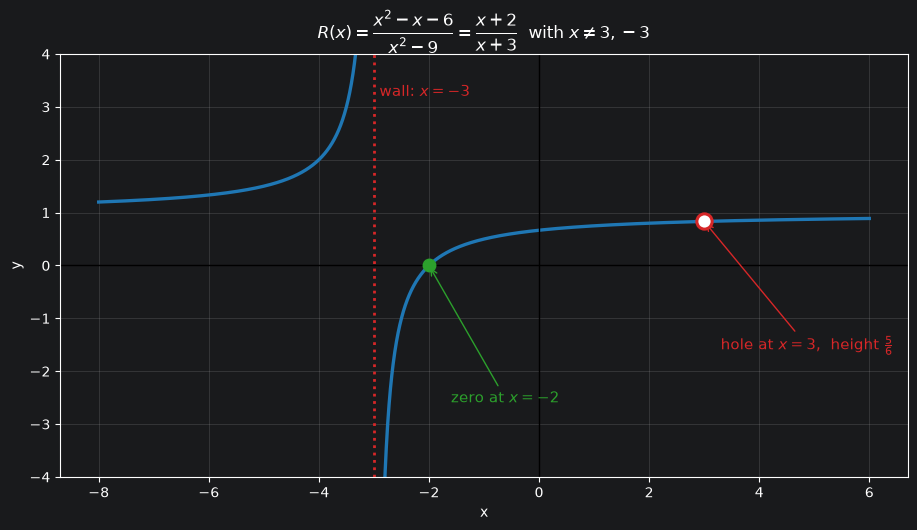

at x = 3.000001:  R(x) = 0.833333
at x = -2.999999:  R(x) = -999998.999875
near x = 3 the value settles at 5/6 = 0.8333333333333334 -> a hole
near x = -3 the value is enormous -> a wall


In [11]:
# --- picture: one expression with a hole, a wall, and a zero ---

x = np.linspace(-8.0, 6.0, 2801)
bad = np.abs(x + 3.0) < 0.03                     # keep away from the wall at x = -3
xs = x[~bad]
R = (xs + 2) / (xs + 3)                          # the REDUCED form (x = 3 handled separately)

fig, ax = plt.subplots(figsize=(9.4, 5.4))

# two branches, cut at the wall
for piece in [xs < -3, xs > -3]:
    ax.plot(xs[piece], R[piece], color=C_MAIN, linewidth=2.4)

ax.axvline(-3, color=C_ALT, linewidth=2.0, linestyle=":")
ax.text(-2.9, 3.2, "wall: $x=-3$", color=C_ALT, fontsize=11)

# the hole at x = 3, height 5/6
ax.plot([3], [5 / 6], "o", markersize=11, markerfacecolor="white",
        markeredgecolor=C_ALT, markeredgewidth=2.2, zorder=5)
ax.annotate(r"hole at $x=3$,  height $\frac{5}{6}$", xy=(3, 5 / 6), xytext=(3.3, -1.6),
            color=C_ALT, fontsize=11, arrowprops=dict(arrowstyle="->", color=C_ALT))

# the zero at x = -2
ax.plot([-2], [0], "o", color=C_FILL, markersize=9, zorder=5)
ax.annotate(r"zero at $x=-2$", xy=(-2, 0), xytext=(-1.6, -2.6), color=C_FILL, fontsize=11,
            arrowprops=dict(arrowstyle="->", color=C_FILL))

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_ylim(-4, 4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$R(x)=\dfrac{x^2-x-6}{x^2-9}=\dfrac{x+2}{x+3}$  with $x\neq 3,-3$")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# The two forbidden points, checked numerically:
for c in (3.0, -3.0):
    near = c + 1e-6
    print(f"at x = {near}:  R(x) = {((near**2 - near - 6) / (near**2 - 9)):.6f}")
print("near x = 3 the value settles at 5/6 =", 5 / 6, "-> a hole")
print("near x = -3 the value is enormous -> a wall")

---

## 6. Python demonstrations

Three tools, all already installed:

* **sympy** (`sp`) — exact algebra with symbols. It never rounds, so it is our judge.
* **numpy** (`np`) — fast arrays, for plotting and for floating-point experiments.
* **matplotlib** (`plt`) — the pictures.

### 6.1 A SymPy tour for fractions

Five commands do almost everything in this notebook. Learn what each one *promises*, because
they are not interchangeable.

| command | what it does |
| --- | --- |
| `sp.factor(e)` | factor a polynomial |
| `sp.cancel(e)` | write as one fraction in **lowest terms** (Theorem 6) |
| `sp.together(e)` | put a sum of fractions over a **common denominator** (Theorem 4ii) |
| `sp.apart(e)` | **partial fractions** — the opposite of `together` (Theorem 11) |
| `sp.simplify(e)` | try everything; slow, and it decides for itself what "simpler" means |

In [12]:
import sympy as sp                    # sp = SymPy, the exact-algebra tool
import numpy as np
import matplotlib.pyplot as plt

x, y, h = sp.symbols("x y h")         # symbols: SymPy keeps these as letters, not numbers

e1 = (x**2 - 9) / (x**2 - x - 6)      # Example 2 of section 5
print("expression      :", e1)
print("factored        :", sp.factor(e1))
print("cancelled       :", sp.cancel(e1))        # -> (x + 3)/(x + 2)
print()

e2 = 3 / (x**2 - 1) + 2 / (x**2 + 2*x + 1)       # Example 6
print("sum of two      :", e2)
print("over one bottom :", sp.together(e2))
print("in lowest terms :", sp.cancel(sp.together(e2)))
print()

e3 = (5*x - 4) / ((x - 2) * (x + 1))             # Example 11
print("one fraction    :", e3)
print("partial fractions:", sp.apart(e3))        # -> 2/(x - 2) + 3/(x + 1)

expression      : (x**2 - 9)/(x**2 - x - 6)
factored        : (x + 3)/(x + 2)
cancelled       : (x + 3)/(x + 2)

sum of two      : 2/(x**2 + 2*x + 1) + 3/(x**2 - 1)
over one bottom : (5*x**2 + 6*x + 1)/((x**2 - 1)*(x**2 + 2*x + 1))
in lowest terms : (5*x + 1)/(x**3 + x**2 - x - 1)

one fraction    : (5*x - 4)/((x - 2)*(x + 1))
partial fractions: 3/(x + 1) + 2/(x - 2)


### 6.2 Finding the domain, and drawing the graph honestly

Two jobs that beginners get wrong in code.

**The domain** is the set of real roots of the denominator **as written**. `sp.fraction` splits
an expression into (top, bottom); `sp.solve` finds the roots. Note we must ask for the **real**
roots.

Here is a real warning about libraries, and it is Trap 2 wearing a disguise: `sp.together`
quietly cancels common factors. If you call it first, SymPy hands you a *smaller* denominator
and the forbidden points disappear. The code below shows this happening, so you can see that
even a trusted tool will take your domain away if you let it.

**The picture.** If you plot a rational function naively, matplotlib joins the two sides of a
wall with a nearly vertical line that is not part of the graph. The fix is to insert `np.nan`
("not a number") wherever the function is undefined: matplotlib draws nothing there and the
curve breaks cleanly.

In [13]:
def forbidden_values(expr):
    """Return the real x where the denominator of `expr`, AS WRITTEN, is zero (Definition 2)."""
    top, bottom = sp.fraction(expr)                  # split into numerator and denominator
    if bottom == 1:                                  # a sum of fractions has no single bottom yet
        top, bottom = sp.fraction(sp.together(expr))  # only then may we combine them
    roots = sp.solve(sp.Eq(bottom, 0), x)            # solve bottom = 0
    return sorted([r for r in roots if r.is_real], key=float)     # keep only the real ones


for e in [5 / (x - 4),
          (x + 1) / (x**2 - x - 6),
          x**3 / (x**2 + 1),
          (x**2 - 1) / (x**3 - x),
          1 / (x - 1) + 1 / (x + 2)]:
    print(f"{str(e):<28} forbidden: {forbidden_values(e)}")

print()
print("Now the warning. The same expression, with sp.together called first:")
bad = (x**2 - 1) / (x**3 - x)
print("   as written :", sp.fraction(bad), "-> forbidden", forbidden_values(bad))
print("   after together:", sp.fraction(sp.together(bad)),
      "-> it thinks only 0 is forbidden")
print("   but at x = 1 the ORIGINAL is 0/0, which is not a number. The domain is x != 0, 1, -1.")

5/(x - 4)                    forbidden: [4]
(x + 1)/(x**2 - x - 6)       forbidden: [-2, 3]
x**3/(x**2 + 1)              forbidden: []
(x**2 - 1)/(x**3 - x)        forbidden: [-1, 0, 1]
1/(x + 2) + 1/(x - 1)        forbidden: [-2, 1]

Now the warning. The same expression, with sp.together called first:
   as written : (x**2 - 1, x**3 - x) -> forbidden [-1, 0, 1]
   after together: (1, x) -> it thinks only 0 is forbidden
   but at x = 1 the ORIGINAL is 0/0, which is not a number. The domain is x != 0, 1, -1.


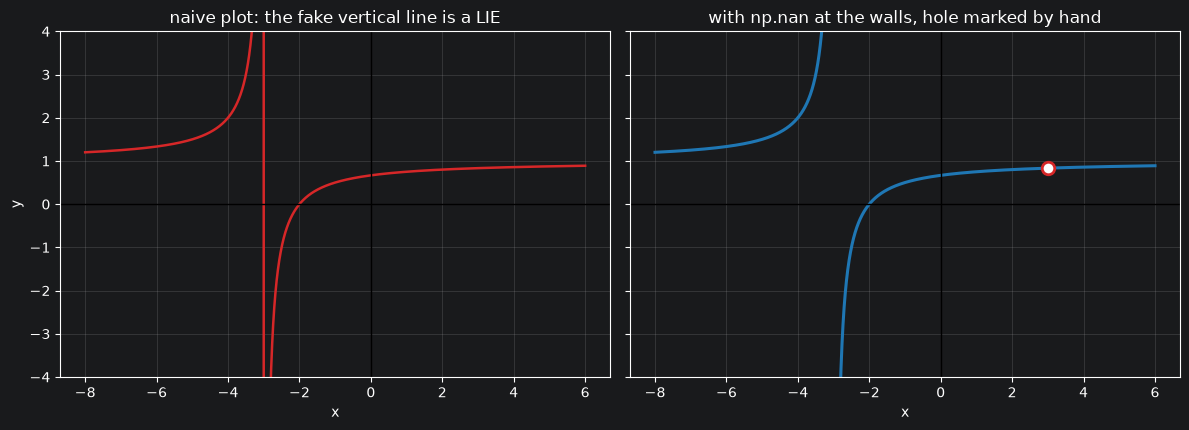

In [14]:
def rational_values(expr, xs, ymax=20.0, eps=1e-9):
    """Evaluate `expr` on the array xs, putting np.nan wherever the curve must be broken.

    Two things get blanked out:
      * the forbidden points themselves (division by zero);
      * anything with |y| > ymax, i.e. the part of a wall that leaves the picture -- otherwise
        matplotlib joins the two sides of the wall with a line that is not part of the graph.
    """
    f = sp.lambdify(x, expr, "numpy")            # turn the SymPy expression into a fast function
    with np.errstate(divide="ignore", invalid="ignore"):
        ys = np.array(f(xs), dtype=float)
    for c in forbidden_values(expr):             # blank out a tiny window around each bad point
        ys[np.abs(xs - float(c)) < eps] = np.nan
    ys[np.abs(ys) > ymax] = np.nan               # blank out the off-screen part of every wall
    return ys


xs = np.linspace(-8.0, 6.0, 4001)
expr = (x**2 - x - 6) / (x**2 - 9)               # Example 12

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), sharey=True)

# LEFT: the naive plot -- matplotlib joins across the wall and draws a line that is NOT there
f_naive = sp.lambdify(x, expr, "numpy")
with np.errstate(divide="ignore", invalid="ignore"):   # ignore the 1/0 warnings on purpose
    axes[0].plot(xs, f_naive(xs), color=C_ALT, linewidth=1.8)
axes[0].set_title("naive plot: the fake vertical line is a LIE")

# RIGHT: the honest plot, using np.nan
axes[1].plot(xs, rational_values(expr, xs, ymax=8.0), color=C_MAIN, linewidth=2.2)
# and the hole at x = 3 drawn by hand, because a single missing point is invisible otherwise
axes[1].plot([3], [5 / 6], "o", markersize=9, markerfacecolor="white",
             markeredgecolor=C_ALT, markeredgewidth=2.0, zorder=5)
axes[1].set_title("with np.nan at the walls, hole marked by hand")

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_ylim(-4, 4)
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("y")
fig.tight_layout()
plt.show()

### 6.3 Checking a claim: subtract and simplify to zero

The habit from notebook 05. Two expressions are equal exactly when their difference simplifies
to $0$. Here we use it as a **trap detector** — the traps of § 4 fail this test, loudly.

In [15]:
claims = [
    ("(x+3)/x  ==  3",                  (x + 3) / x - 3),                       # Trap 1
    ("(x-3)/(3-x)  ==  -1",             (x - 3) / (3 - x) - (-1)),              # Trap 3
    ("1/x + 1/y  ==  1/(x+y)",          1/x + 1/y - 1/(x + y)),                 # Trap 4
    ("(2x+1)/(x-3) - (x-4)/(x-3)  ==  (x+5)/(x-3)",
     (2*x + 1)/(x - 3) - (x - 4)/(x - 3) - (x + 5)/(x - 3)),                    # Example 7
    ("(1/x + 1/y)/(1/x - 1/y)  ==  (x+y)/(y-x)",
     (1/x + 1/y) / (1/x - 1/y) - (x + y)/(y - x)),                              # Example 8
]

for name, difference in claims:
    verdict = sp.simplify(difference) == 0
    print(f"{'TRUE ' if verdict else 'FALSE'}  {name}")

FALSE  (x+3)/x  ==  3
TRUE   (x-3)/(3-x)  ==  -1
FALSE  1/x + 1/y  ==  1/(x+y)
TRUE   (2x+1)/(x-3) - (x-4)/(x-3)  ==  (x+5)/(x-3)
TRUE   (1/x + 1/y)/(1/x - 1/y)  ==  (x+y)/(y-x)


### 6.4 Building the LCD ourselves (Theorem 8)

`sp.factor_list` returns the factorisation as **data**: a constant, then a list of
(factor, exponent) pairs. That is exactly the form Theorem 8 needs — take the highest exponent
of each factor.

In [16]:
def my_lcd(q1, q2):
    """Least common denominator of two polynomials, built by Theorem 8."""
    powers = {}                                   # factor -> highest exponent seen so far
    for q in (q1, q2):
        const, pairs = sp.factor_list(q)          # e.g. (1, [(x - 1, 2), (x + 2, 1)])
        for factor, exponent in pairs:
            key = sp.srepr(factor)                # a text key, so equal factors match
            best = powers.get(key, (factor, 0))[1]
            powers[key] = (factor, max(best, exponent))
    out = sp.Integer(1)
    for factor, exponent in powers.values():
        out = out * factor**exponent              # multiply the highest powers together
    return out


q1 = sp.expand((x - 1)**2 * (x + 2))
q2 = sp.expand((x - 1) * (x + 2)**3 * (x + 5))
mine = my_lcd(q1, q2)
theirs = sp.lcm(sp.Poly(q1, x), sp.Poly(q2, x)).as_expr()      # SymPy's own lcm, as the judge

print("q1        =", sp.factor(q1))
print("q2        =", sp.factor(q2))
print("my LCD    =", sp.factor(mine))
print("SymPy lcm =", sp.factor(theirs))
# Equal up to a constant is all Theorem 8 promises, so compare the factored forms by dividing:
print("ratio (should be a constant):", sp.cancel(mine / theirs))

q1        = (x - 1)**2*(x + 2)
q2        = (x - 1)*(x + 2)**3*(x + 5)
my LCD    = (x - 1)**2*(x + 2)**3*(x + 5)
SymPy lcm = (x - 1)**2*(x + 2)**3*(x + 5)
ratio (should be a constant): 1


### 6.5 Partial fractions and Lagrange interpolation, from scratch

The cover-up formula of Theorem 11 is one line of code, because it is one line of algebra. Then
we build Lagrange interpolation (Theorem 10) and draw it — the same formula, seen the other way
round.

In [17]:
def cover_up(p_expr, roots):
    """Partial fractions for distinct linear factors, by the cover-up formula (Theorem 11)."""
    out = []
    for i, r_i in enumerate(roots):
        bottom = sp.Integer(1)
        for j, r_j in enumerate(roots):
            if j != i:
                bottom = bottom * (r_i - r_j)     # the product over j != i
        A_i = sp.simplify(p_expr.subs(x, r_i) / bottom)
        out.append((A_i, r_i))
    return out


roots = [sp.Integer(2), sp.Integer(-1)]           # q = (x-2)(x+1)
p_expr = 5*x - 4
pieces = cover_up(p_expr, roots)
print("cover-up gives:", " + ".join(f"({A})/(x - ({r}))" for A, r in pieces))

rebuilt = sum(A / (x - r) for A, r in pieces)
original = p_expr / ((x - 2) * (x + 1))
print("SymPy apart   :", sp.apart(original))
print("difference simplifies to zero?", sp.simplify(rebuilt - original) == 0)
print()

# A harder one: three distinct roots.
roots3 = [sp.Integer(0), sp.Integer(1), sp.Integer(-2)]
p3 = x**2 + 3
q3 = x * (x - 1) * (x + 2)
pieces3 = cover_up(p3, roots3)
rebuilt3 = sum(A / (x - r) for A, r in pieces3)
print("p/q       =", p3 / q3)
print("cover-up  =", rebuilt3)
print("SymPy     =", sp.apart(p3 / q3))
print("difference simplifies to zero?", sp.simplify(rebuilt3 - p3 / q3) == 0)

cover-up gives: (2)/(x - (2)) + (3)/(x - (-1))
SymPy apart   : 3/(x + 1) + 2/(x - 2)
difference simplifies to zero? True

p/q       = (x**2 + 3)/(x*(x - 1)*(x + 2))
cover-up  = 7/(6*(x + 2)) + 4/(3*(x - 1)) - 3/(2*x)
SymPy     = 7/(6*(x + 2)) + 4/(3*(x - 1)) - 3/(2*x)
difference simplifies to zero? True


the interpolating polynomial: -47*x**3/120 + 21*x**2/20 + 227*x/120 - 11/20
   L( -2) = 3   (wanted 3)
   L( -1) = -1   (wanted -1)
   L(  1) = 2   (wanted 2)
   L(  3) = 4   (wanted 4)


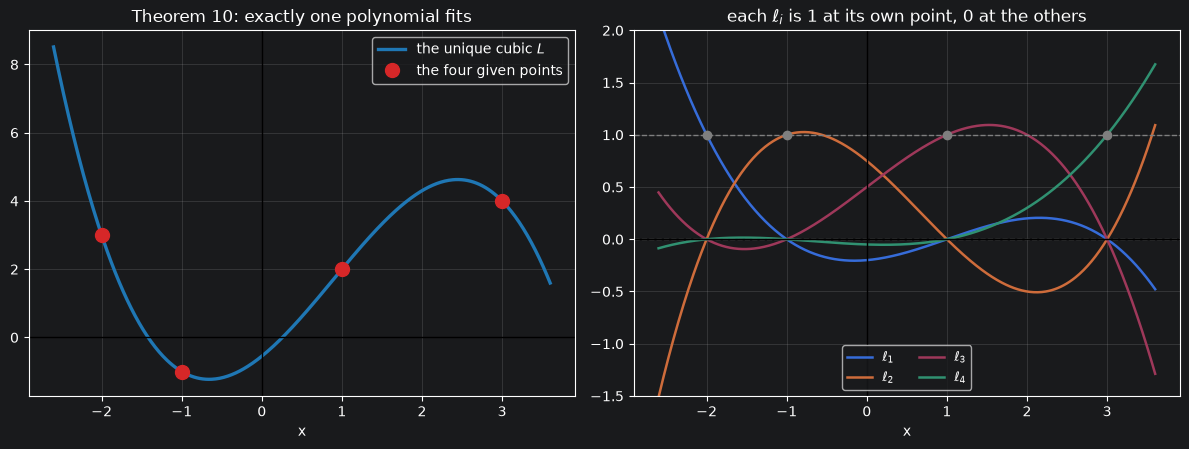

In [18]:
def lagrange(points):
    """The unique polynomial of degree <= n-1 through the given (r, y) points (Theorem 10)."""
    L = sp.Integer(0)
    rs = [sp.Rational(r) for r, _ in points]
    for i, (r_i, y_i) in enumerate(points):
        basis = sp.Integer(1)
        for j, r_j in enumerate(rs):
            if j != i:
                basis = basis * (x - r_j) / (sp.Rational(r_i) - r_j)   # the switch l_i(x)
        L = L + sp.Rational(y_i) * basis
    return sp.expand(L)


points = [(-2, 3), (-1, -1), (1, 2), (3, 4)]        # four points -> degree at most 3
L = lagrange(points)
print("the interpolating polynomial:", L)
for r, yv in points:                                 # it must pass through every point exactly
    print(f"   L({r:>3}) = {L.subs(x, r)}   (wanted {yv})")

# --- picture: one polynomial through the points, and the four "switch" polynomials ---
xs = np.linspace(-2.6, 3.6, 500)
f = sp.lambdify(x, L, "numpy")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

axes[0].plot(xs, f(xs), color=C_MAIN, linewidth=2.4, label="the unique cubic $L$")
axes[0].plot([p[0] for p in points], [p[1] for p in points], "o", color=C_ALT, markersize=10,
             label="the four given points")
axes[0].set_title("Theorem 10: exactly one polynomial fits")
axes[0].legend(fontsize=10)

# the basis polynomials: each is 1 at its own point and 0 at the others
rs = [p[0] for p in points]
for i, r_i in enumerate(rs):
    basis = sp.Integer(1)
    for j, r_j in enumerate(rs):
        if j != i:
            basis = basis * (x - r_j) / (r_i - r_j)
    g = sp.lambdify(x, sp.expand(basis), "numpy")
    axes[1].plot(xs, g(xs), linewidth=1.8, label=rf"$\ell_{i+1}$")
axes[1].plot(rs, [1] * len(rs), "o", color=C_GREY, markersize=6)
axes[1].axhline(1, color=C_GREY, linewidth=1, linestyle="--")
axes[1].axhline(0, color=C_GREY, linewidth=1, linestyle="--")
axes[1].set_ylim(-1.5, 2.0)
axes[1].set_title(r"each $\ell_i$ is 1 at its own point, 0 at the others")
axes[1].legend(fontsize=9, ncol=2)

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### 6.6 The warning: **simplifying a rational expression makes it numerically safe**

This is the fifth numerical-analysis lesson of the course. The earlier four were:

* nb 03 — catastrophic cancellation in the distance formula;
* nb 04 — the same, in the expanded $(x-1)^{7}$;
* nb 05 — ill-conditioning (Wilkinson's polynomial);
* nb 06 — deflation order.

This one is the friendliest, because for once the algebra **fixes** the problem instead of
revealing one.

Take Example 10 again, at $x=2$:

$$\frac{\dfrac{1}{x+h}-\dfrac1x}{h} \qquad\text{against}\qquad \frac{-1}{x(x+h)} .$$

They are the same expression (we proved it). But the left form subtracts two nearly equal
numbers and then divides by a tiny $h$ — and subtracting nearly equal numbers is exactly the
catastrophic cancellation of notebook 03. The right form never subtracts anything.

Prediction: as $h$ shrinks, the left form gets **worse**, not better, while the right form stays
perfect. Let us measure.

In [19]:
from fractions import Fraction     # exact fractions: our judge, because it never rounds

x0 = 2.0
hs = [10.0**(-k) for k in range(1, 17)]                  # h = 1e-1 down to 1e-16

naive, smart, err_naive, err_smart = [], [], [], []
for hv in hs:
    a = (1.0 / (x0 + hv) - 1.0 / x0) / hv                # the dangerous form
    b = -1.0 / (x0 * (x0 + hv))                          # the simplified form

    # The exact value of the SAME quotient, using the numbers actually stored in the computer.
    # Fraction(a_float) is the exact rational value of that float, so nothing is lost here.
    Fx, Fh = Fraction(x0), Fraction(hv)
    exact = (Fraction(1) / (Fx + Fh) - Fraction(1) / Fx) / Fh

    naive.append(a)
    smart.append(b)
    err_naive.append(float(abs(Fraction(a) - exact)))     # exact comparison, no rounding
    err_smart.append(float(abs(Fraction(b) - exact)))

hs = np.array(hs)
err_naive = np.array(err_naive)
err_smart = np.array(err_smart)

print(f"{'h':>10} | {'naive form':>20} | {'simplified':>20} | {'err naive':>10} | {'err smart':>10}")
for hv, a, b, e1, e2 in zip(hs, naive, smart, err_naive, err_smart):
    print(f"{hv:>10.0e} | {a:>20.16f} | {b:>20.16f} | {e1:>10.2e} | {e2:>10.2e}")

         h |           naive form |           simplified |  err naive |  err smart
     1e-01 |  -0.2380952380952384 |  -0.2380952380952381 |   2.65e-16 |   1.26e-17
     1e-02 |  -0.2487562189054660 |  -0.2487562189054727 |   6.68e-15 |   3.34e-17
     1e-03 |  -0.2498750624687629 |  -0.2498750624687656 |   2.72e-15 |   1.36e-18
     1e-04 |  -0.2499875006256591 |  -0.2499875006249687 |   6.90e-13 |   3.45e-17
     1e-05 |  -0.2499987500070855 |  -0.2499987500062500 |   8.35e-13 |   4.18e-18
     1e-06 |  -0.2499998750238319 |  -0.2499998750000625 |   2.38e-11 |   1.19e-17
     1e-07 |  -0.2499999868232905 |  -0.2499999875000007 |   6.77e-10 |   3.38e-17
     1e-08 |  -0.2499999984806323 |  -0.2499999987500000 |   2.69e-10 |   1.35e-18
     1e-09 |  -0.2500000206850927 |  -0.2499999998750000 |   2.08e-08 |   1.04e-17
     1e-10 |  -0.2500000206850927 |  -0.2499999999875000 |   2.07e-08 |   1.03e-18
     1e-11 |  -0.2500000206850927 |  -0.2499999999987500 |   2.07e-08 |   1.03e-19
    

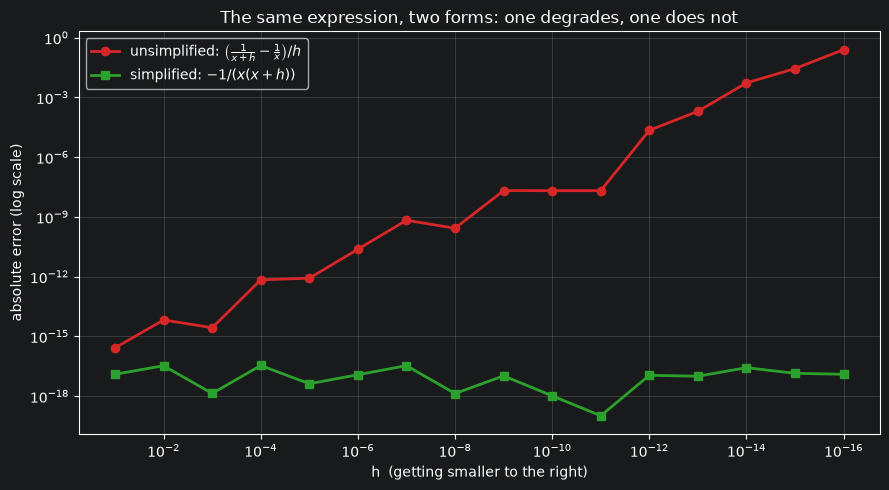

In [20]:
# --- picture: the error of the two forms, as h shrinks ---

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.loglog(hs, np.maximum(err_naive, 1e-20), "o-", color=C_ALT, linewidth=2.0,
          label="unsimplified: $\\left(\\frac{1}{x+h}-\\frac{1}{x}\\right)/h$")
ax.loglog(hs, np.maximum(err_smart, 1e-20), "s-", color=C_FILL, linewidth=2.0,
          label=r"simplified: $-1/(x(x+h))$")
ax.invert_xaxis()                                  # h shrinks to the right, like a limit
ax.set_xlabel("h  (getting smaller to the right)")
ax.set_ylabel("absolute error (log scale)")
ax.set_title("The same expression, two forms: one degrades, one does not")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

**What the picture says.** The green line sits on the floor: the simplified form is exact to the
last digit for every $h$. The red line climbs as $h$ shrinks — at $h=10^{-16}$ the naive form has
lost every correct digit, and for small enough $h$ it returns exactly $0$, which is not even
close.

Three lessons:

1. **Two algebraically equal expressions are not equally good to compute with.** This is now the
   fifth time the course has said it, and it will keep being true.
2. The fix here was **doing the algebra first** — cancelling the $h$. The mathematics you learned
   in this notebook is not only tidier, it is more accurate.
3. This is also *why* calculus does the cancellation by hand before letting $h$ go to zero. If it
   did not, no computer could follow.

---

## 7. Exercises

Twenty exercises, easy first and hard last. Rules I will hold you to:

* **every** answer that came from cancelling carries its restrictions, written out;
* every simplification gets a check with one number;
* in a proof, name the theorem you use at each step.

### Exercise 1 — domains

Find the domain of each expression. Say which theorem tells you the answer is "all of
$\mathbb{R}$ minus a finite set".

(a) $\dfrac{7}{x+5}$
(b) $\dfrac{x-2}{x^{2}-4}$
(c) $\dfrac{x^{2}+1}{x^{2}+4}$
(d) $\dfrac{3x}{x^{3}-2x^{2}-3x}$

In [ ]:
# your work for Exercise 1

### Exercise 2 — lowest terms

Simplify, and write the restrictions.

(a) $\dfrac{x^{2}-25}{x^{2}+10x+25}$
(b) $\dfrac{2x^{2}-8}{x^{2}-x-2}$
(c) $\dfrac{x^{3}-x}{x^{2}+x}$
(d) $\dfrac{x^{2}+2x+1}{x^{3}+1}$  (hint: sum of cubes, notebook 05 Theorem 4)

In [ ]:
# your work for Exercise 2

### Exercise 3 — reversed brackets (Trap 3)

Simplify, with restrictions.

(a) $\dfrac{4-x}{x-4}$
(b) $\dfrac{25-x^{2}}{x^{2}-3x-10}$
(c) $\dfrac{(3-x)(x+1)}{(x-3)(x-1)}$

In [ ]:
# your work for Exercise 3

### Exercise 4 — multiply and divide

Factor first, never multiply out. Restrictions on every answer.

(a) $\dfrac{x^{2}-1}{x^{2}+5x+6}\cdot\dfrac{x+3}{x-1}$
(b) $\dfrac{x^{2}-9}{x^{2}+x}\div\dfrac{x-3}{x^{2}-1}$
(c) $\dfrac{2x^{2}+7x+3}{x^{2}-4}\cdot\dfrac{x^{2}-2x}{4x^{2}-1}$

In [ ]:
# your work for Exercise 4

### Exercise 5 — add and subtract

Use the LCD of Theorem 8, and keep the denominators factored.

(a) $\dfrac{2}{x-1}+\dfrac{3}{x+2}$
(b) $\dfrac{x}{x^{2}-4}-\dfrac{1}{x+2}$
(c) $\dfrac{1}{x^{2}-x}+\dfrac{2}{x^{2}-1}$

In [ ]:
# your work for Exercise 5

### Exercise 6 — the minus sign (Trap 5)

(a) Simplify $\dfrac{3x-2}{x+4}-\dfrac{2x-6}{x+4}$.
(b) A student writes $\dfrac{3x-2-2x-6}{x+4}=\dfrac{x-8}{x+4}$. Find the exact place where the
mistake happens, then show with one value of $x$ that the answer is wrong.

In [ ]:
# your work for Exercise 6

### Exercise 7 — complex fractions

Do each one **twice**: once by Method A (top and bottom separately) and once by Method B
(multiply everything by the inner LCD). The two answers must agree.

(a) $\dfrac{\;1+\dfrac{1}{x}\;}{\;1-\dfrac{1}{x^{2}}\;}$

(b) $\dfrac{\;\dfrac{1}{x+h}-\dfrac{1}{x}\;}{\;h\;}$  (this is Example 10 — do it your own way,
then compare)

In [ ]:
# your work for Exercise 7

### Exercise 8 — polynomial part + proper part (Theorem 7)

(a) $\dfrac{x^{3}-4x^{2}+2x+1}{x-3}$ — use synthetic division (notebook 06).
(b) $\dfrac{2x^{2}+5x-1}{x+4}$ — synthetic division again.
(c) $\dfrac{x^{4}+1}{x^{2}+1}$ — synthetic division does **not** apply here. Say why in one
sentence, then do it with long division (notebook 04).

In [ ]:
# your work for Exercise 8

### Exercise 9 — difference quotients

Simplify $\dfrac{f(x+h)-f(x)}{h}$ as far as possible, for $h\neq0$:

(a) $f(x)=\dfrac{1}{x^{2}}$
(b) $f(x)=\dfrac{x}{x+1}$
(c) $f(x)=\dfrac{2}{3x-1}$

In each case say what happens to your simplified answer when $h$ becomes very small. (You do
not have to prove it — just describe it. We will make it exact when we do limits.)

In [ ]:
# your work for Exercise 9

### Exercise 10 — hole or wall?

For each expression: reduce, then classify **every** forbidden point using Theorem 9. Give the
height of any hole.

(a) $\dfrac{x^{2}-4}{x^{2}-x-2}$
(b) $\dfrac{x+1}{x^{2}-1}$
(c) $\dfrac{x^{3}-x}{x^{2}-2x+1}$

Then sketch (a) by hand, or plot it with matplotlib, and mark the hole with an open circle.

In [ ]:
# your work for Exercise 10

### Exercise 11 — partial fractions by cover-up

Use Theorem 11. Check each answer by adding the pieces back together.

(a) $\dfrac{7x-1}{(x-1)(x+2)}$
(b) $\dfrac{x+5}{x^{2}-x-6}$
(c) $\dfrac{2x^{2}+x+1}{x(x-1)(x+1)}$

In [ ]:
# your work for Exercise 11

### Exercise 12 — a real problem

You cycle to school at $u$ km/h and come back along the same road at $v$ km/h.

(a) Let the distance be $d$. Write the total time as one rational expression in $u,v,d$.
(b) Show that the **average speed** for the whole trip is
$$\bar{s}=\frac{2uv}{u+v},$$
and notice that the $d$ cancels — the answer does not depend on how far the school is.
(c) Take $u=10$ and $v=30$. Is $\bar s$ equal to $20$? Explain in one sentence why the average
speed is *not* the average of the speeds.
(d) Prove that $\bar s$ is always less than or equal to $\dfrac{u+v}{2}$, with equality only when
$u=v$. (Hint: subtract the two and show the difference has a squared factor.)

In [ ]:
# your work for Exercise 12

### Exercise 13 — Python: domains and honest graphs

Write a function `describe(expr)` that prints, for a rational expression given as a SymPy
expression:

* the forbidden values;
* the reduced form (`sp.cancel`);
* for each forbidden value, whether it is a **hole** or a **wall**, and the height of the hole.

Test it on the three expressions of Exercise 10, and on $\dfrac{x^{2}-x-6}{x^{2}-9}$ from
Example 12. Then plot one of them with `np.nan` at the forbidden points, and mark the hole with
an open circle.

In [ ]:
# your work for Exercise 13

### Exercise 14 — Python: your own `cancel`

Write `to_lowest_terms(p, q)` that uses `sp.factor_list` on the top and the bottom, removes the
factors they share (taking the smaller exponent of each), and returns the reduced pair.

Do **not** call `sp.cancel` inside your function — but do use it to check your answer on at
least five examples, including one where nothing cancels and one where everything cancels.

In [ ]:
# your work for Exercise 14

### Exercise 15 — Python: cover-up, and where it stops working

(a) Write your own `cover_up(p, roots)` (Theorem 11) and check it against `sp.apart` on three
expressions with distinct linear factors.
(b) Now feed it $\dfrac{1}{(x-1)^{2}}$, whose factor is repeated. What does your function
produce, and what does `sp.apart` produce?
(c) Explain in two sentences **which hypothesis of Theorem 11 fails**, and why the proof breaks
at that exact point. (Look at the Lagrange step.)

In [ ]:
# your work for Exercise 15

### Exercise 16 — Python: repeat the numerical experiment

Take $f(x)=\dfrac{1}{x^{2}}$ at $x_{0}=1$.

(a) Write both forms of the difference quotient: the raw one, and the one you simplified in
Exercise 9(a).
(b) Evaluate both for $h=10^{-k}$, $k=1,\dots,17$.
(c) Compute the exact value with `fractions.Fraction`, and plot the error of each form on a
log-log axis, as in § 6.6.
Then repeat (b) with $h=2^{-k}$ instead. The picture changes — powers of two are stored exactly,
so some of the damage disappears. Say in one sentence which of the two experiments is the more
honest test of the *formula*, and why.
(d) Below which $h$ does the raw form return exactly $0$? Explain why that happens.

In [ ]:
# your work for Exercise 16

### Exercise 17 — proof: an equation that is almost never true

(a) Show by one counterexample that $\dfrac1a+\dfrac1b=\dfrac{1}{a+b}$ is not an identity.
(b) Now find **all** real pairs $(a,b)$, with $a,b,a+b$ all non-zero, for which it *is* true.
Do it properly: clear the denominators, collect everything on one side, and use the
discriminant (notebook 05 Theorem 8) to decide whether any real solution exists.
(c) State your conclusion as a theorem, in one sentence.

In [ ]:
# your work for Exercise 17

### Exercise 18 — proof: the reduced denominator divides the original

**Claim.** If $\dfrac pq=\dfrac ab$ with $\dfrac ab$ in lowest terms, then $b$ divides $q$.

(a) Prove it. (Hint: cross-multiply with Theorem 2, then use Lemma 6b.)
(b) Deduce that every forbidden point of $\dfrac ab$ is also a forbidden point of $\dfrac pq$ —
in words: reducing can only *remove* forbidden points, never add new ones.
(c) Why does part (b) matter for Theorem 9?

In [ ]:
# your work for Exercise 18

### Exercise 19 — proof: partial fractions the slow way

Let $r_{1}\neq r_{2}$ and let $p$ have degree $\le1$.

(a) Prove directly, **without** using Lagrange interpolation, that there are constants $A,B$ with
$$\frac{p(x)}{(x-r_{1})(x-r_{2})}=\frac{A}{x-r_{1}}+\frac{B}{x-r_{2}} .$$
(Multiply up, compare coefficients using the identity theorem, and solve the two equations. Show
that the system always has exactly one solution — this is where $r_{1}\neq r_{2}$ is used.)
(b) Show that your $A$ and $B$ agree with the cover-up formula of Theorem 11.
(c) In one sentence, say what the Lagrange proof gave us that this one does not.

In [ ]:
# your work for Exercise 19

### Exercise 20 — proof: $\sqrt{x}$ is not a rational expression

This is the capstone, and it is the same proof as "$\sqrt2$ is irrational" from notebook 01 —
with **degree** playing the role of size, exactly as in notebook 05 § 3.9.

**Claim.** There is no rational expression $R\in\mathbb{R}(x)$ with $R^{2}=x$.

(a) Suppose there were. Write $R=\dfrac ab$ in lowest terms (Theorem 6) and show that
$a^{2}=x\,b^{2}$.
(b) Take degrees of both sides and derive a contradiction. (Use notebook 04 Theorem 2.)
(c) Write two or three sentences comparing this proof with the proof that $\sqrt2\notin\mathbb{Q}$
in notebook 01. Which step plays the role of "even numbers"? Where is the lowest-terms
assumption used in each?
(d) This is exactly why the next topic exists. Guess, in one sentence, what $\sqrt{x}$ *is*, if
it is neither a polynomial nor a rational expression.

In [ ]:
# your work for Exercise 20

---

## 8. Still owed

Honest list of things this notebook used or mentioned but did not prove:

* **Limits.** Theorem 9 proved the algebra of a wall, but "the values run off to infinity" is a
  limit statement. Owed until the calculus chapter.
* **Asymptotes properly.** Vertical, horizontal and oblique asymptotes belong to the chapter on
  rational *functions*, later in the syllabus.
* **Partial fractions in general.** We proved only the case of **distinct linear** factors.
  Repeated factors $(x-r)^{k}$ and irreducible quadratics need more work.
* **Why `sp.cancel` is fast.** Real systems use the Euclidean algorithm for polynomial gcd, not
  full factorisation. We proved the mathematics; the good algorithm is a separate story.

---

## 9. How to run this project with `uv`

`uv` is the tool that keeps this project's Python packages together, so the notebook runs the
same way every time.

```bash
uv sync                 # install everything listed in pyproject.toml
uv run jupyter lab      # start JupyterLab, then open notebooks/07-rational-expressions.ipynb
```

This notebook uses only **numpy**, **sympy** and **matplotlib**, which are already dependencies.
No new package was needed.

Never write an `import` for a package that is not in `pyproject.toml`. If a later notebook needs
one, add it first:

```bash
uv add pandas           # example only; not needed here
```

To check that the whole notebook still runs from top to bottom:

```bash
uv run jupyter nbconvert --to notebook --execute notebooks/07-rational-expressions.ipynb --stdout > /dev/null
```

---

### Where we go next

Syllabus topic 8 is **nth Roots; Rational Exponents** — and Exercise 20 is the door to it. We
will have proved that $\sqrt x$ is not a polynomial and not a rational expression, so it must be
a genuinely new kind of object. Notebook 08 builds it, defines $x^{1/n}$ and then $x^{m/n}$, and
proves that the exponent laws of notebook 02 survive the extension.

Before we move on, be ready to answer these out loud:

1. Why is the domain read off the **original** expression and not the simplified one?
2. Cancelling a factor is Theorem 3. What exactly stops you cancelling a term?
3. What are the two meanings of "equal" for rational expressions, and which theorem says they
   agree?
4. $\mathbb{R}[x]$ is not a field but $\mathbb{R}(x)$ is. Which single axiom is the difference,
   and what did we pay for it?
5. Which theorem promises that two people who simplify the same fraction differently still get
   the same answer?
6. In the cover-up formula, why is the number $\prod_{j\neq i}(r_{i}-r_{j})$ never zero?